# 🌍 Middle East Conflict Data — EDA
**데이터**: ACLED 기반 중동 분쟁 집계 데이터 (2015–2026)

---
### 분석 목차
1. 라이브러리 & 데이터 로드
2. 기본 데이터 탐색
3. 결측값 처리
4. 연도별 추이 분석
5. 국가별 분석
6. 사건 유형 분석
7. 분쟁 카테고리 분석
8. 최근 동향 (2024–2026)
9. 지리적 분포 시각화
10. 상관관계 분석

## 1. 라이브러리 & 데이터 로드

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows


plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

sns.set_palette('tab10')

FILE_PATH = 'Middle-East_aggregated_data_up_to-2026-03-07.csv'

df_raw = pd.read_csv(FILE_PATH, parse_dates=['WEEK'])
print(f'원본 shape: {df_raw.shape}')
df_raw.head()

원본 shape: (144526, 13)


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,2026-03-07,Middle East,Bahrain,Capital,Explosions/Remote violence,Air/drone strike,7,1,NaN,Political violence,285.0,26.1927,50.5508
1,2026-03-07,Middle East,Bahrain,Capital,Protests,Peaceful protest,8,0,NaN,Demonstrations,285.0,26.1927,50.5508
2,2026-03-07,Middle East,Bahrain,Capital,Strategic developments,Arrests,2,0,NaN,Strategic developments,285.0,26.1927,50.5508
3,2026-03-07,Middle East,Bahrain,Capital,Strategic developments,Disrupted weapons use,8,0,NaN,Strategic developments,285.0,26.1927,50.5508
4,2026-03-07,Middle East,Bahrain,Muharraq,Explosions/Remote violence,Air/drone strike,3,0,NaN,Political violence,286.0,26.2547,50.6428


## 2. 기본 데이터 탐색

In [4]:
print('=== 컬럼 목록 & 타입 ===')
print(df_raw.dtypes)
print()
print('=== 기술 통계 ===')
df_raw.describe()

=== 컬럼 목록 & 타입 ===
WEEK                   datetime64[ns]
REGION                         object
COUNTRY                        object
ADMIN1                         object
EVENT_TYPE                     object
SUB_EVENT_TYPE                 object
EVENTS                          int64
FATALITIES                      int64
POPULATION_EXPOSURE           float64
DISORDER_TYPE                  object
ID                            float64
CENTROID_LATITUDE             float64
CENTROID_LONGITUDE            float64
dtype: object

=== 기술 통계 ===


,WEEK,EVENTS,FATALITIES,POPULATION_EXPOSURE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
count,144526,144526.000000,144526.000000,1.136730e+05,144516.000000,144526.000000,144526.000000
mean,2021-05-30 23:00:25.656283136,4.055685,3.787097,7.812755e+04,2605.757861,30.230652,41.219421
min,2014-12-27 00:00:00,1.000000,0.000000,1.000000e+00,285.000000,4.769000,26.695700
25%,2019-01-05 00:00:00,1.000000,0.000000,1.179700e+04,1375.000000,28.272800,36.227300
50%,2021-07-10 00:00:00,2.000000,0.000000,3.111800e+04,3183.000000,33.283200,42.349600
75%,2023-12-23 00:00:00,3.000000,1.000000,7.867100e+04,3410.000000,36.026500,44.788000
max,2026-03-07 00:00:00,324.000000,8102.000000,8.229442e+06,4187.000000,42.938500,62.976100
std,NaN,9.273627,35.143457,1.631214e+05,1007.790430,8.712500,6.035345


In [5]:
print('=== 컬럼별 유니크 값 (범주형) ===')
cat_cols = ['REGION', 'COUNTRY', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'DISORDER_TYPE']
for col in cat_cols:
    vals = df_raw[col].dropna().unique()
    print(f'\n[{col}] ({len(vals)}개)')
    print(vals)

=== 컬럼별 유니크 값 (범주형) ===

[REGION] (1개)
['Middle East']

[COUNTRY] (15개)
['Bahrain' 'Iran' 'Iraq' 'Israel' 'Jordan' 'Kuwait' 'Lebanon' 'Oman'
 'Palestine' 'Qatar' 'Saudi Arabia' 'Syria' 'Turkey'
 'United Arab Emirates' 'Yemen']

[EVENT_TYPE] (6개)
['Explosions/Remote violence' 'Protests' 'Strategic developments' 'Riots'
 'Battles' 'Violence against civilians']

[SUB_EVENT_TYPE] (25개)
['Air/drone strike' 'Peaceful protest' 'Arrests' 'Disrupted weapons use'
 'Violent demonstration' 'Shelling/artillery/missile attack' 'Other'
 'Looting/property destruction' 'Armed clash' 'Attack'
 'Change to group/activity' 'Headquarters or base established'
 'Remote explosive/landmine/IED' 'Mob violence'
 'Abduction/forced disappearance' 'Grenade' 'Protest with intervention'
 'Excessive force against protesters' 'Non-violent transfer of territory'
 'Agreement' 'Government regains territory' 'Suicide bomb'
 'Non-state actor overtakes territory' 'Chemical weapon' 'Sexual violence']

[DISORDER_TYPE] (4개)
['Po

## 3. 결측값 처리

                      결측 수  결측률(%)
POPULATION_EXPOSURE  30853    21.3
ID                      10     0.0


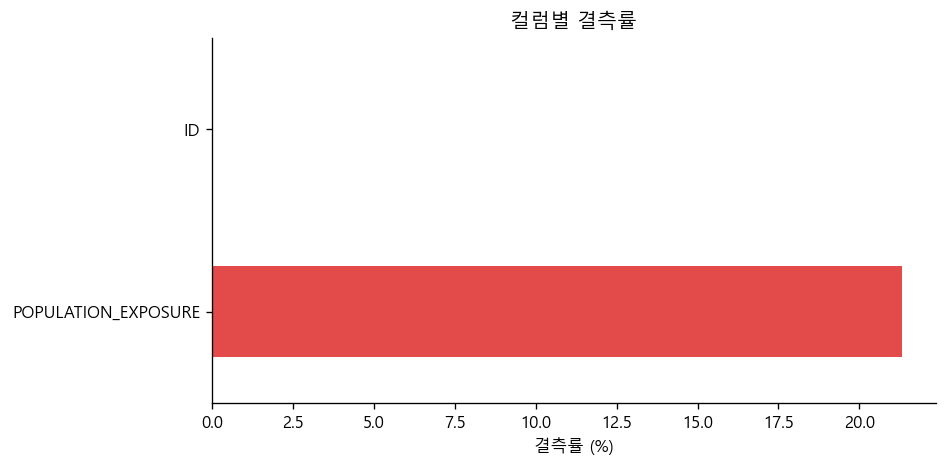

In [6]:
# 결측값 현황
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'결측 수': missing, '결측률(%)': missing_pct})
print(missing_df[missing_df['결측 수'] > 0])

fig, ax = plt.subplots(figsize=(8, 4))
missing_df[missing_df['결측 수'] > 0]['결측률(%)'].plot(kind='barh', ax=ax, color='#E24B4A')
ax.set_xlabel('결측률 (%)')
ax.set_title('컬럼별 결측률')
plt.tight_layout()
plt.show()

In [7]:
# WEEK 기준으로 결측 제거 → 분석용 df 생성
df = df_raw.dropna(subset=['WEEK']).copy()
df['YEAR'] = df['WEEK'].dt.year
df['MONTH'] = df['WEEK'].dt.month
df['YEARMONTH'] = df['WEEK'].dt.to_period('M')

print(f'정제 후 shape: {df.shape}')
print(f'기간: {df["WEEK"].min().date()} ~ {df["WEEK"].max().date()}')

정제 후 shape: (144526, 16)
기간: 2014-12-27 ~ 2026-03-07


## 4. 연도별 추이 분석

In [8]:
yearly = df.groupby('YEAR')[['EVENTS', 'FATALITIES']].sum().reset_index()
print(yearly.to_string(index=False))

 YEAR  EVENTS  FATALITIES
 2014      15          27
 2015    8576       18594
 2016   32803       80901
 2017   57085      107250
 2018   52476       72812
 2019   54396       48773
 2020   48106       31731
 2021   50228       28027
 2022   51840       16371
 2023   60540       36709
 2024   91712       45594
 2025   64133       29817
 2026   14242       30728


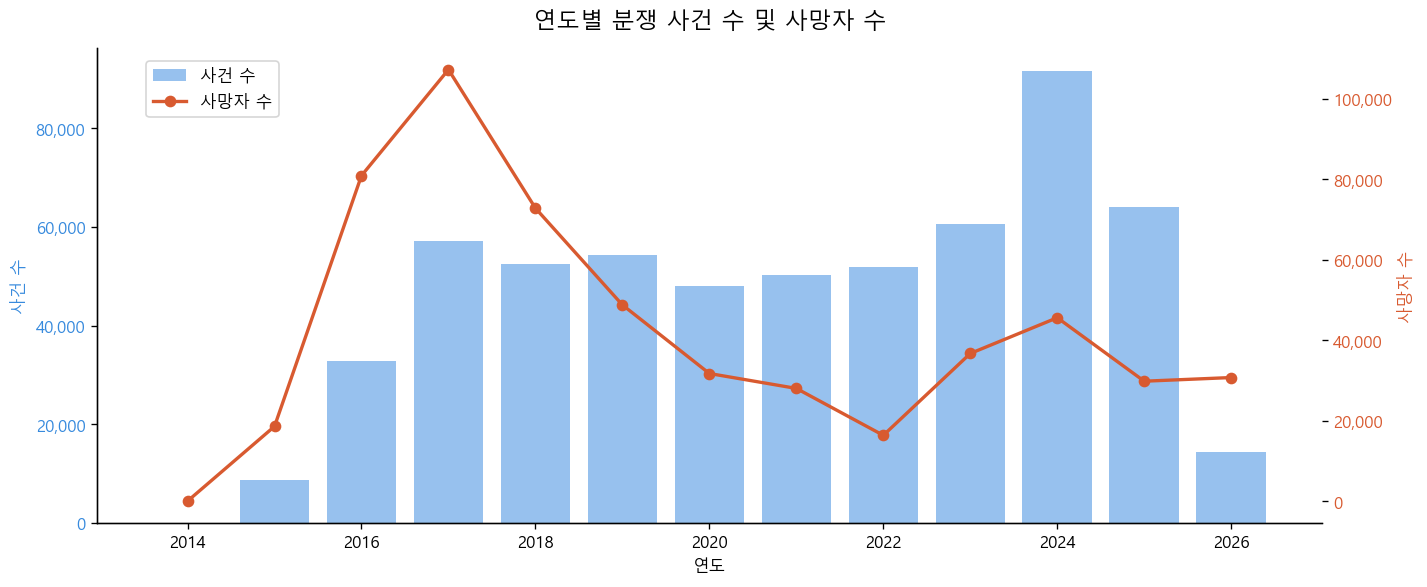

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(yearly['YEAR'], yearly['EVENTS'], color='#85B7EB', label='사건 수', alpha=0.85)
ax1.set_xlabel('연도')
ax1.set_ylabel('사건 수', color='#378ADD')
ax1.tick_params(axis='y', labelcolor='#378ADD')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(yearly['YEAR'], yearly['FATALITIES'], color='#D85A30', marker='o',
         linewidth=2, markersize=6, label='사망자 수')
ax2.set_ylabel('사망자 수', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax1.set_title('연도별 분쟁 사건 수 및 사망자 수', fontsize=14, pad=12)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

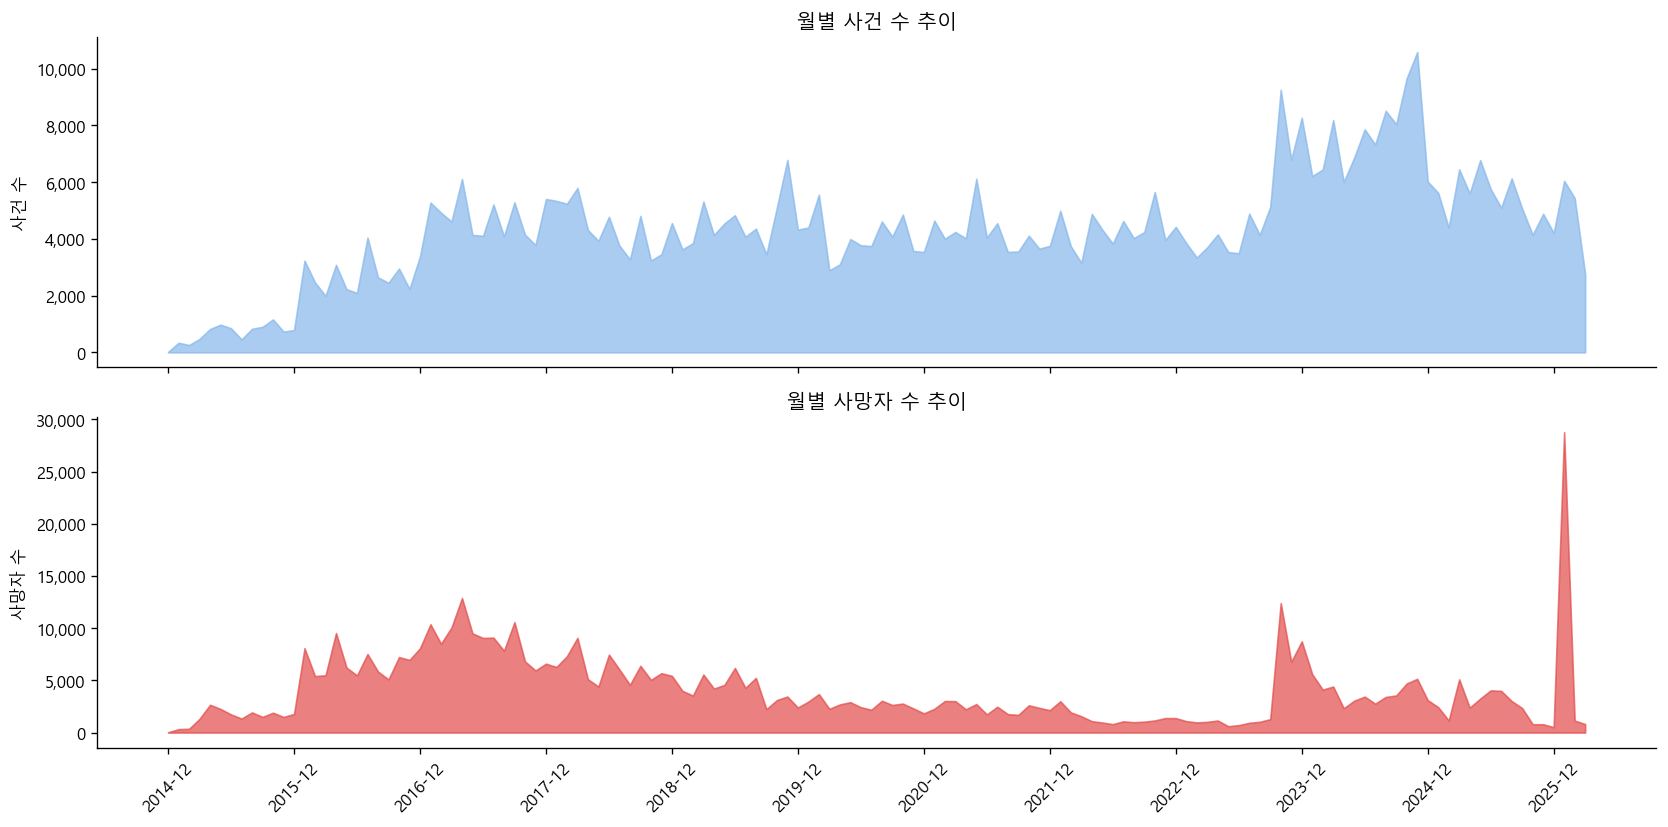

In [10]:
# 월별 추이 (전체 기간)
monthly = df.groupby('YEARMONTH')[['EVENTS', 'FATALITIES']].sum().reset_index()
monthly['YEARMONTH_str'] = monthly['YEARMONTH'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].fill_between(monthly['YEARMONTH_str'], monthly['EVENTS'], alpha=0.7, color='#85B7EB')
axes[0].set_ylabel('사건 수')
axes[0].set_title('월별 사건 수 추이')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].fill_between(monthly['YEARMONTH_str'], monthly['FATALITIES'], alpha=0.7, color='#E24B4A')
axes[1].set_ylabel('사망자 수')
axes[1].set_title('월별 사망자 수 추이')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# x축 레이블 간격 조정
tick_positions = list(range(0, len(monthly), 12))
for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([monthly['YEARMONTH_str'].iloc[i] for i in tick_positions], rotation=45)

plt.tight_layout()
plt.show()

## 5. 국가별 분석

In [11]:
country_agg = df.groupby('COUNTRY')[['EVENTS', 'FATALITIES']].sum()
country_agg['치명률(사건당)'] = (country_agg['FATALITIES'] / country_agg['EVENTS']).round(2)
country_agg = country_agg.sort_values('FATALITIES', ascending=False)
print(country_agg)

                      EVENTS  FATALITIES  치명률(사건당)
COUNTRY                                           
Yemen                 112820      166972      1.48
Syria                 149288      142994      0.96
Iraq                   67478      107616      1.59
Palestine              92350       72186      0.78
Iran                   36582       32811      0.90
Turkey                 49156        9710      0.20
Saudi Arabia            3612        6501      1.80
Lebanon                36598        6224      0.17
Israel                 19570        2040      0.10
Jordan                  4039         204      0.05
Bahrain                14146          24      0.00
Oman                      90          21      0.23
Kuwait                   189          13      0.07
United Arab Emirates     131          12      0.09
Qatar                    103           6      0.06


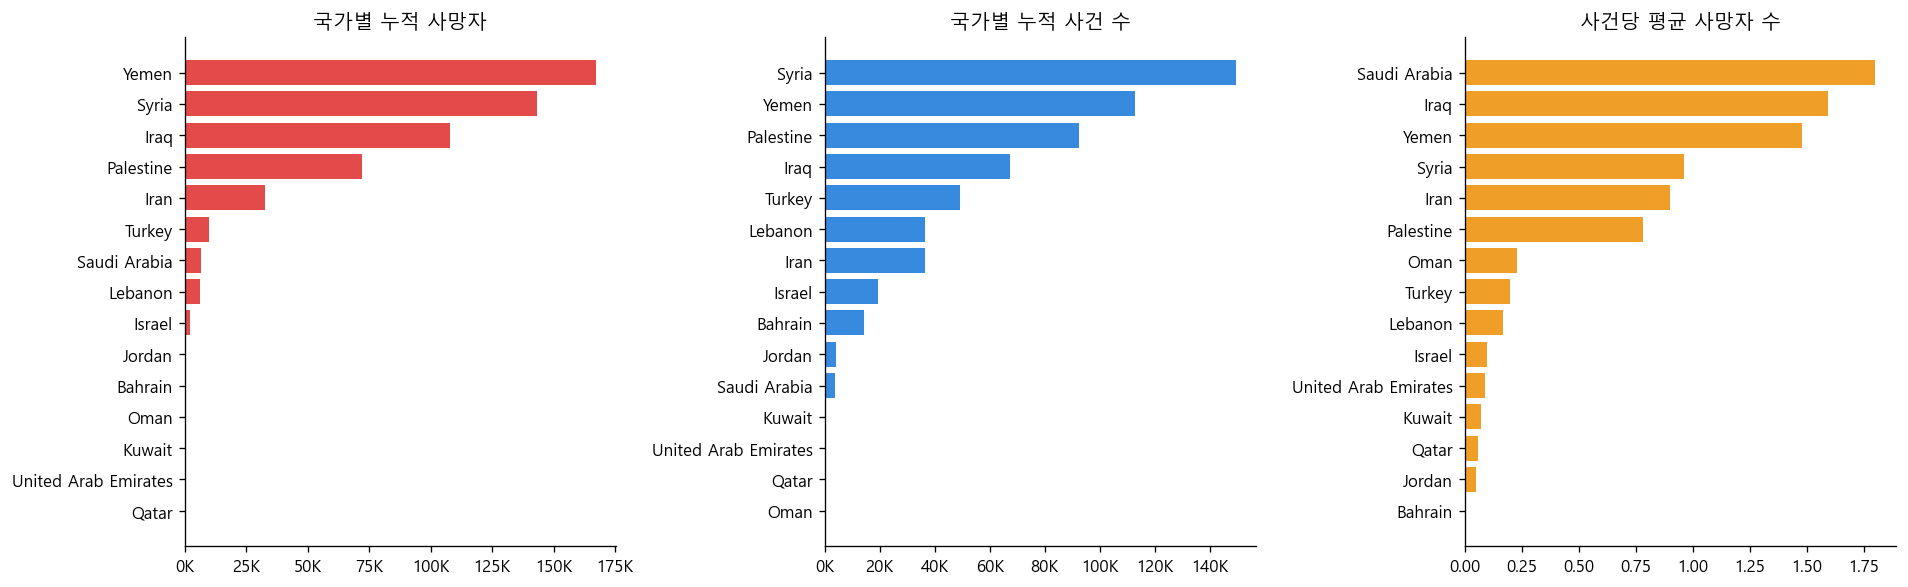

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 누적 사망자
top_fatal = country_agg['FATALITIES'].sort_values()
axes[0].barh(top_fatal.index, top_fatal.values, color='#E24B4A')
axes[0].set_title('국가별 누적 사망자')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# 누적 사건 수
top_events = country_agg['EVENTS'].sort_values()
axes[1].barh(top_events.index, top_events.values, color='#378ADD')
axes[1].set_title('국가별 누적 사건 수')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# 사건당 사망자 (치명률)
top_rate = country_agg['치명률(사건당)'].sort_values()
axes[2].barh(top_rate.index, top_rate.values, color='#EF9F27')
axes[2].set_title('사건당 평균 사망자 수')

plt.tight_layout()
plt.show()

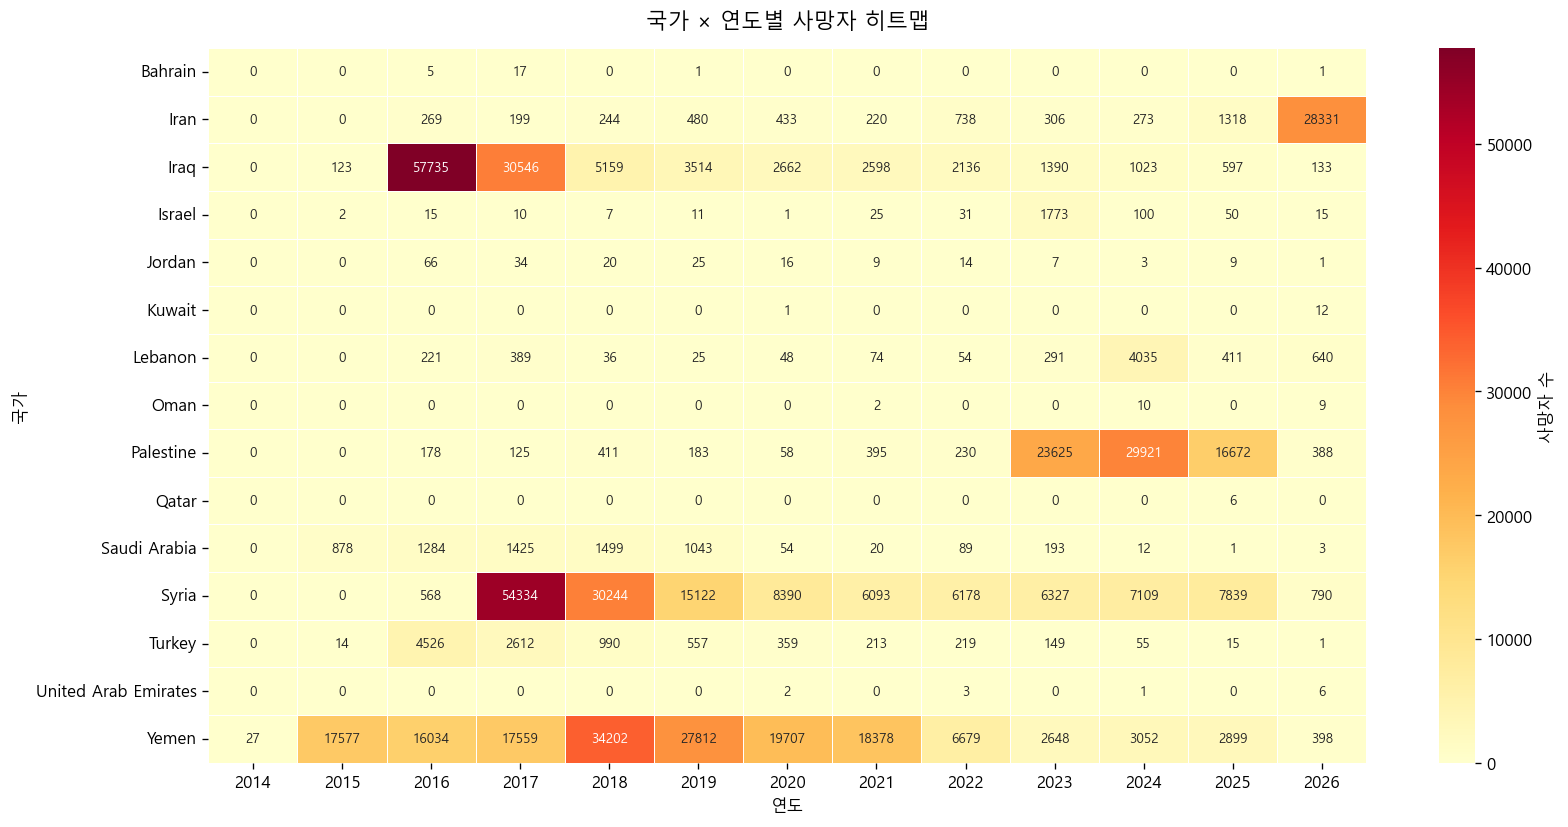

In [13]:
# 국가별 연도별 히트맵 (사망자)
pivot_fatal = df.pivot_table(values='FATALITIES', index='COUNTRY', columns='YEAR', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_fatal, ax=ax, cmap='YlOrRd', fmt='.0f',
            linewidths=0.3, cbar_kws={'label': '사망자 수'},
            annot=True, annot_kws={'size': 8})
ax.set_title('국가 × 연도별 사망자 히트맵', fontsize=13, pad=12)
ax.set_xlabel('연도')
ax.set_ylabel('국가')
plt.tight_layout()
plt.show()

## 6. 사건 유형 분석

In [14]:
event_agg = df.groupby('EVENT_TYPE')[['EVENTS', 'FATALITIES']].sum().sort_values('FATALITIES', ascending=False)
print(event_agg)

                            EVENTS  FATALITIES
EVENT_TYPE                                    
Battles                      84081      244939
Explosions/Remote violence  216662      235863
Violence against civilians   34915       34290
Riots                        46559       25130
Protests                    142788        5408
Strategic developments       61147        1704


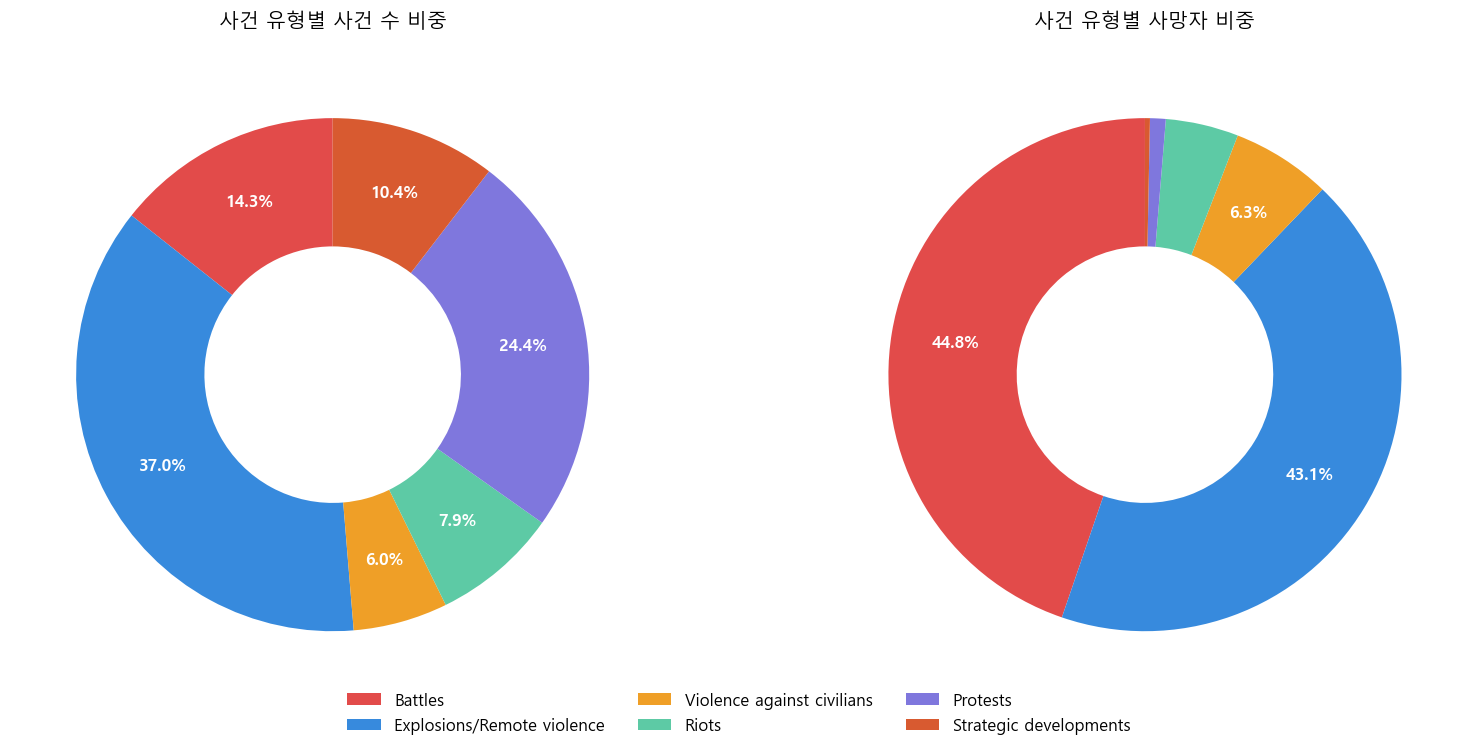

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#E24B4A','#378ADD','#EF9F27','#5DCAA5','#7F77DD','#D85A30']
labels = event_agg.index.tolist()

def make_donut(ax, data, title):
    total = data.sum()
    wedges, _, autotexts = ax.pie(
        data, autopct='%1.1f%%', colors=colors,
        wedgeprops=dict(width=0.5), startangle=90,
        pctdistance=0.75
    )
    for at, val in zip(autotexts, data):
        if val / total < 0.05:   # 5% 미만은 숨김
            at.set_visible(False)
        else:
            at.set_fontsize(10)
            at.set_fontweight('bold')
            at.set_color('white')
    ax.set_title(title, fontsize=12, pad=16)
    return wedges

wedges = make_donut(axes[0], event_agg['EVENTS'], '사건 유형별 사건 수 비중')
make_donut(axes[1], event_agg['FATALITIES'], '사건 유형별 사망자 비중')

fig.legend(wedges, labels,
           loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05),
           fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

In [16]:
# Sub-event 분석
sub_agg = df.groupby('SUB_EVENT_TYPE')[['EVENTS', 'FATALITIES']].sum().sort_values('FATALITIES', ascending=False)
print('=== 세부 사건 유형 TOP 15 (사망자 기준) ===')
print(sub_agg.head(15))

=== 세부 사건 유형 TOP 15 (사망자 기준) ===
                                     EVENTS  FATALITIES
SUB_EVENT_TYPE                                         
Armed clash                           75306      206634
Air/drone strike                      98440      148453
Shelling/artillery/missile attack     94140       46905
Attack                                26994       34284
Remote explosive/landmine/IED         21434       32272
Government regains territory           5954       30452
Violent demonstration                 15098       24500
Non-state actor overtakes territory    2821        7853
Suicide bomb                            657        7417
Excessive force against protesters     1518        5408
Disrupted weapons use                  8650        1008
Other                                 11970         696
Mob violence                          31461         630
Chemical weapon                          85         412
Grenade                                1906         404


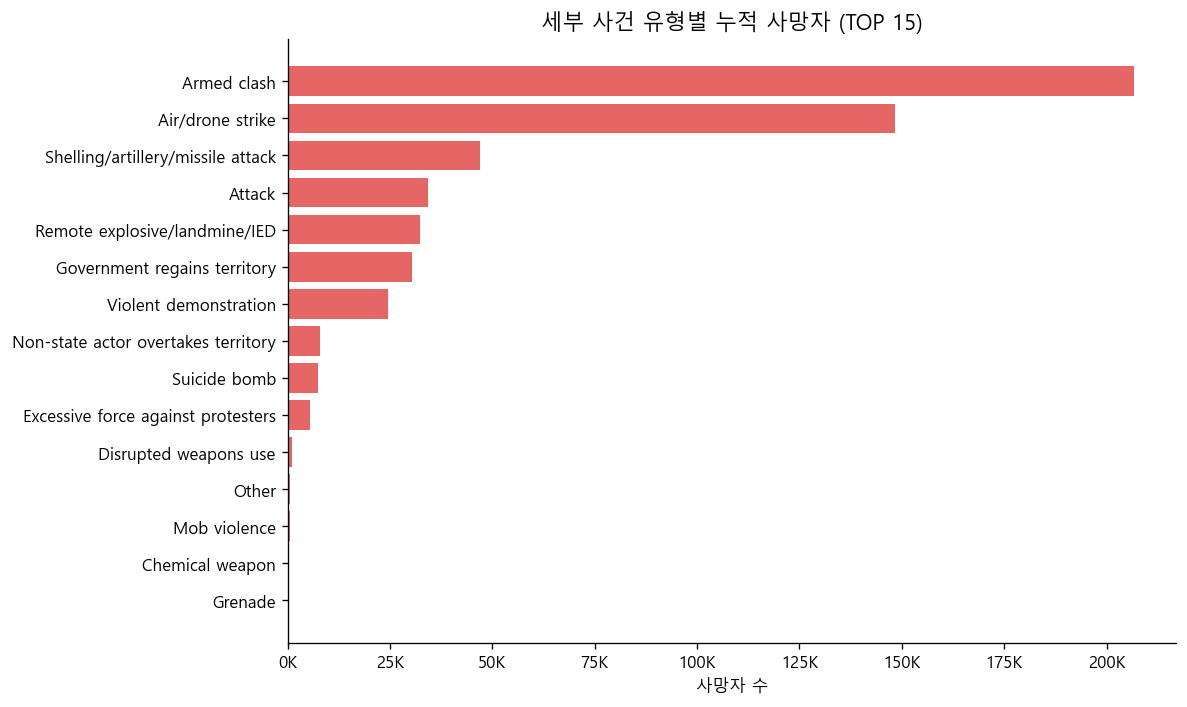

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
top15 = sub_agg.head(15).sort_values('FATALITIES')
ax.barh(top15.index, top15['FATALITIES'], color='#E24B4A', alpha=0.85)
ax.set_title('세부 사건 유형별 누적 사망자 (TOP 15)', fontsize=13)
ax.set_xlabel('사망자 수')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

## 7. 분쟁 카테고리 분석

In [18]:
disorder_agg = df.groupby('DISORDER_TYPE')[['EVENTS', 'FATALITIES']].sum().sort_values('EVENTS', ascending=False)
print(disorder_agg)

                                    EVENTS  FATALITIES
DISORDER_TYPE                                         
Political violence                  367119      515722
Demonstrations                      156368       24500
Strategic developments               61147        1704
Political violence; Demonstrations    1518        5408


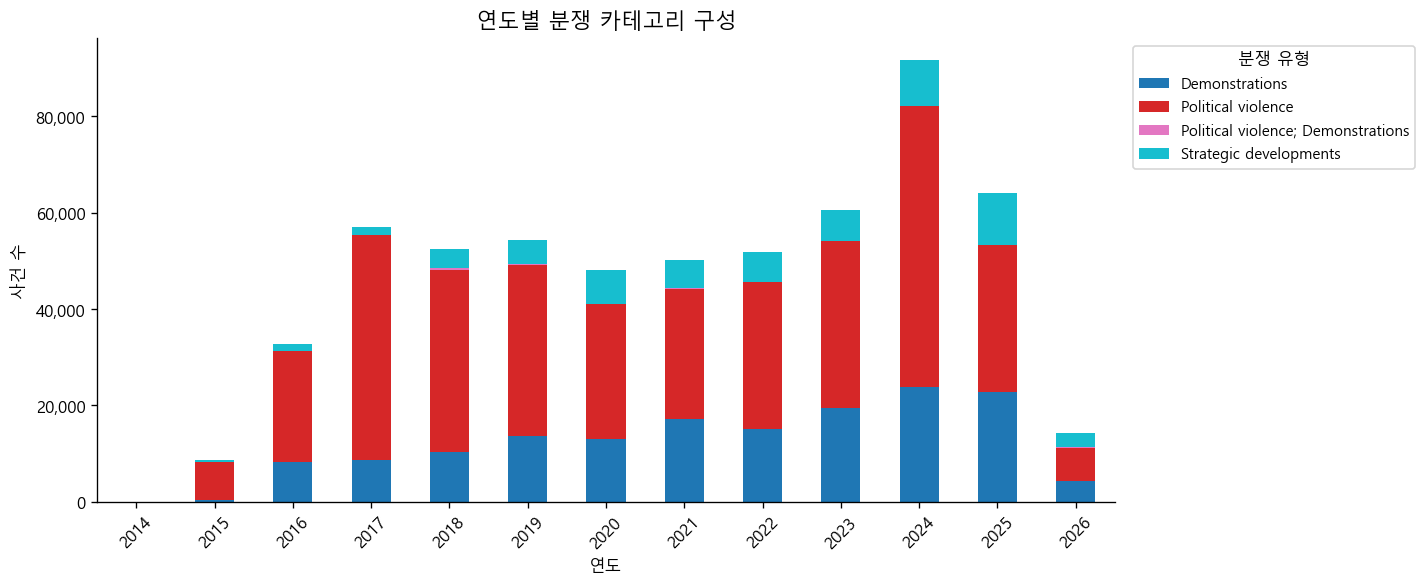

In [19]:
# 연도별 분쟁 카테고리 스택 차트
disorder_yearly = df.groupby(['YEAR', 'DISORDER_TYPE'])['EVENTS'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
disorder_yearly.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('연도별 분쟁 카테고리 구성', fontsize=13)
ax.set_xlabel('연도')
ax.set_ylabel('사건 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='분쟁 유형', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. 최근 동향 (2024–2026)

In [20]:
df_recent = df[df['YEAR'] >= 2024].copy()

print('=== 2024–2026 국가별 현황 ===')
recent_country = df_recent.groupby('COUNTRY')[['EVENTS', 'FATALITIES']].sum().sort_values('FATALITIES', ascending=False)
print(recent_country)

=== 2024–2026 국가별 현황 ===
                      EVENTS  FATALITIES
COUNTRY                                 
Palestine              42127       46981
Iran                   10957       29922
Syria                  28217       15738
Yemen                  27154        6349
Lebanon                19933        5086
Iraq                   15951        1753
Israel                  8585         165
Turkey                 14570          71
Oman                      27          19
Saudi Arabia              80          16
Jordan                   445          13
Kuwait                    71          12
United Arab Emirates      89           7
Qatar                     42           6
Bahrain                 1839           1


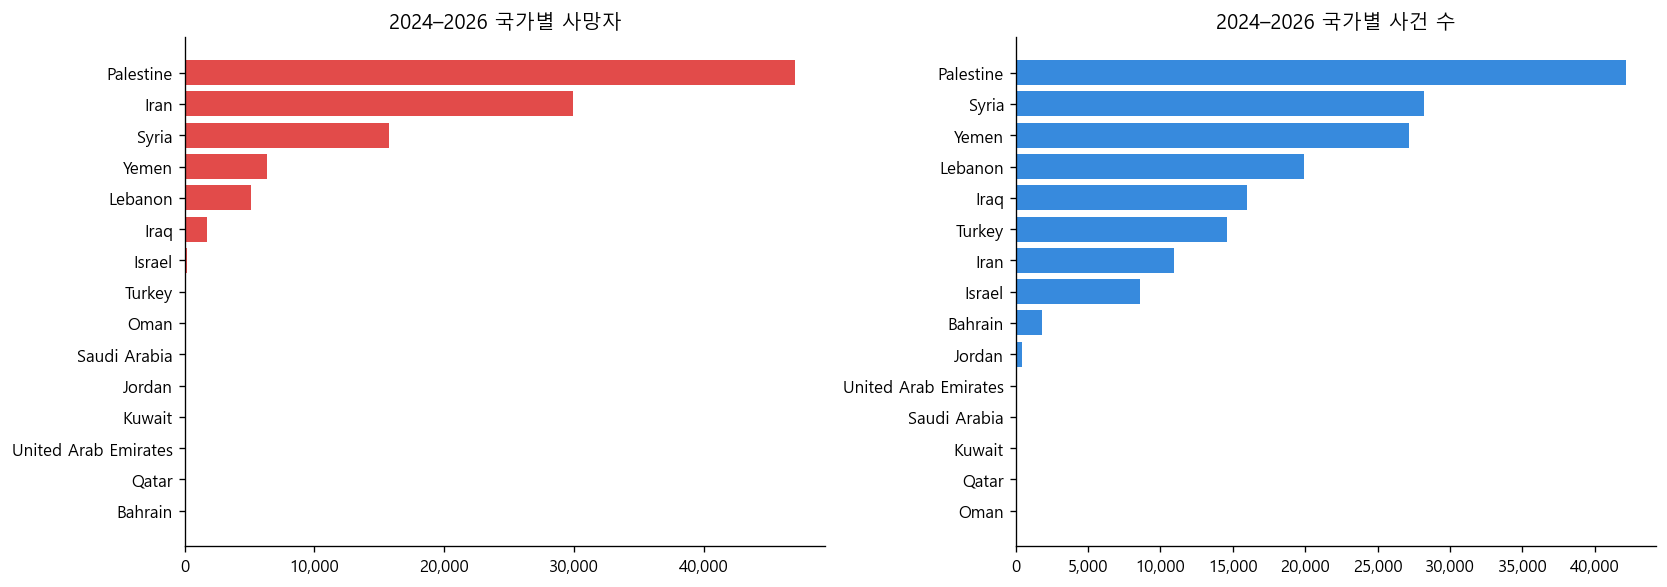

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사망자 비교
rc_fatal = recent_country['FATALITIES'].sort_values(ascending=True)
axes[0].barh(rc_fatal.index, rc_fatal.values, color='#E24B4A')
axes[0].set_title('2024–2026 국가별 사망자')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 사건 수 비교
rc_events = recent_country['EVENTS'].sort_values(ascending=True)
axes[1].barh(rc_events.index, rc_events.values, color='#378ADD')
axes[1].set_title('2024–2026 국가별 사건 수')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

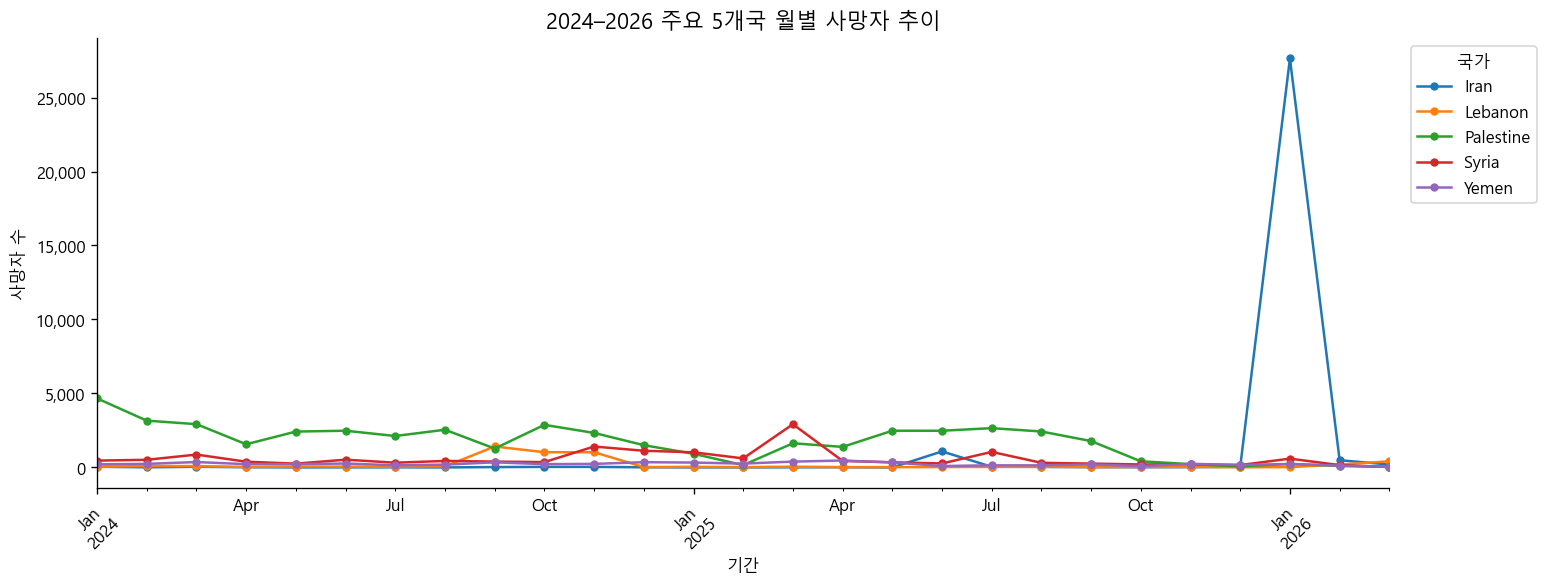

In [22]:
# 2024 이후 주요 국가 월별 추이
top_recent_countries = recent_country.head(5).index.tolist()
df_top = df_recent[df_recent['COUNTRY'].isin(top_recent_countries)]
monthly_country = df_top.groupby(['YEARMONTH', 'COUNTRY'])['FATALITIES'].sum().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
monthly_country.plot(ax=ax, marker='o', markersize=4, linewidth=1.5)
ax.set_title('2024–2026 주요 5개국 월별 사망자 추이', fontsize=13)
ax.set_xlabel('기간')
ax.set_ylabel('사망자 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='국가', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. 지리적 분포 시각화

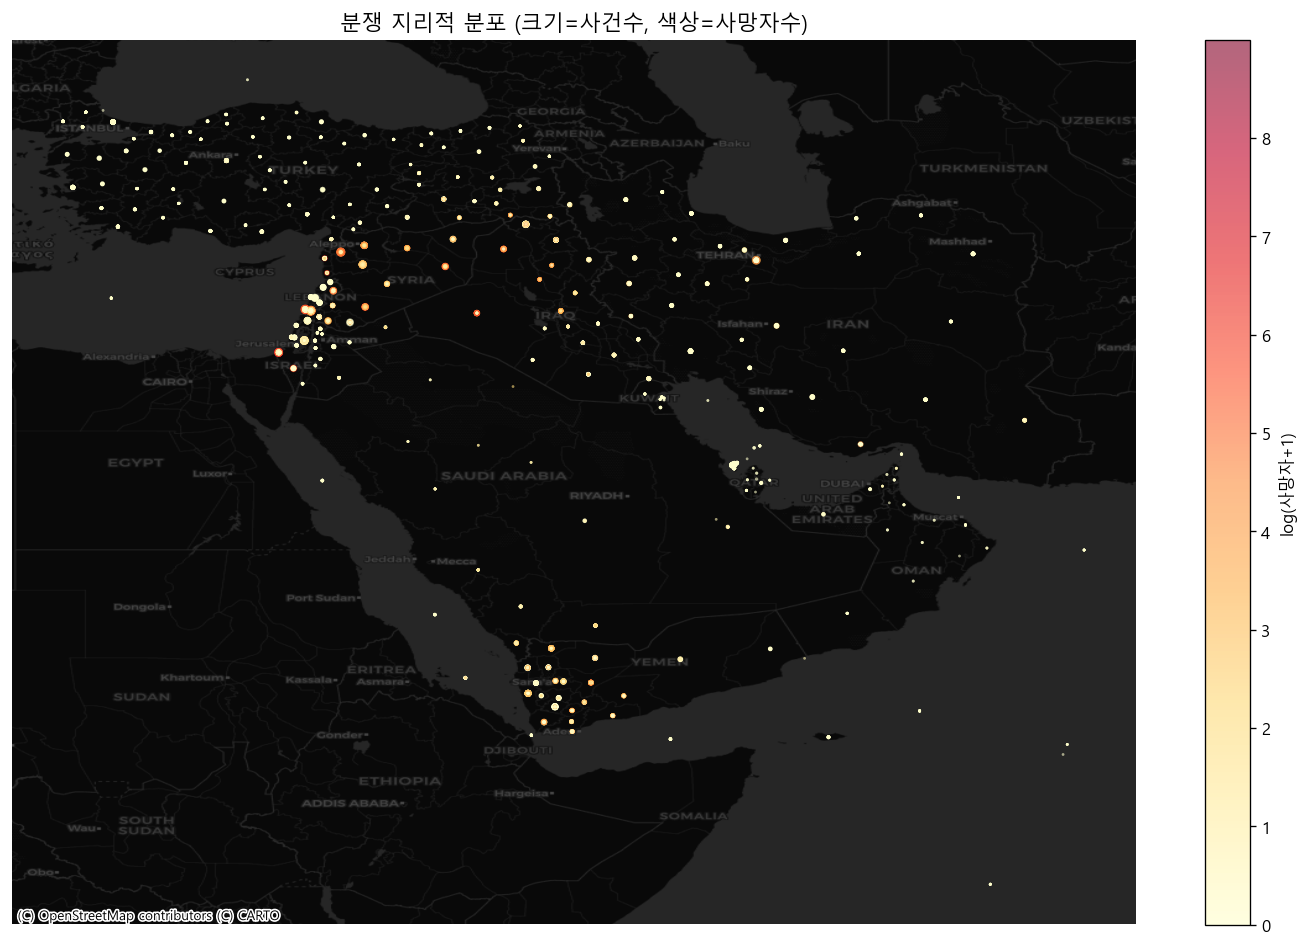

In [32]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

df_geo = df.dropna(subset=['CENTROID_LATITUDE', 'CENTROID_LONGITUDE'])

# GeoDataFrame 변환 (WGS84 → Web Mercator)
gdf = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo['CENTROID_LONGITUDE'], df_geo['CENTROID_LATITUDE']),
    crs='EPSG:4326'
).to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=np.log1p(gdf['FATALITIES']),
    s=np.sqrt(gdf['EVENTS'] + 1) * 2,
    cmap='YlOrRd', alpha=0.6, linewidths=0, zorder=3
)

# 배경지도 추가
ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter, zoom=5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log(사망자+1)')
ax.set_title('분쟁 지리적 분포 (크기=사건수, 색상=사망자수)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 10. 상관관계 분석

                       EVENTS  FATALITIES  POPULATION_EXPOSURE
EVENTS               1.000000    0.279652             0.378279
FATALITIES           0.279652    1.000000             0.212554
POPULATION_EXPOSURE  0.378279    0.212554             1.000000


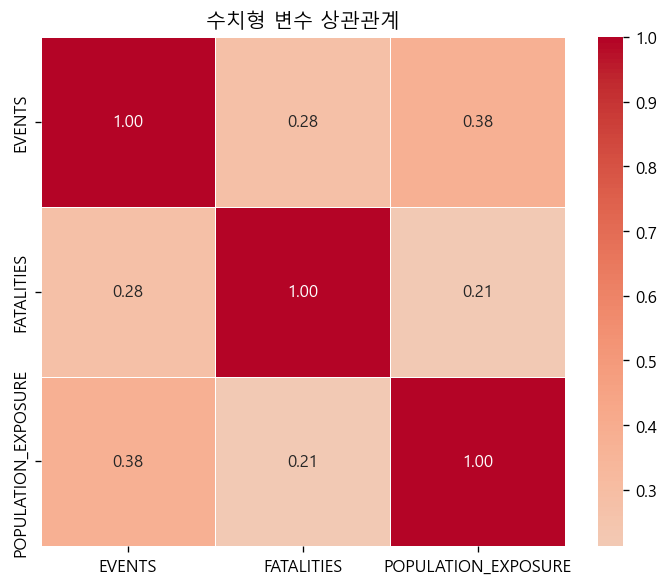

In [25]:
# 수치형 컬럼 상관계수
num_cols = ['EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE']
corr = df[num_cols].corr()
print(corr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('수치형 변수 상관관계')
plt.tight_layout()
plt.show()

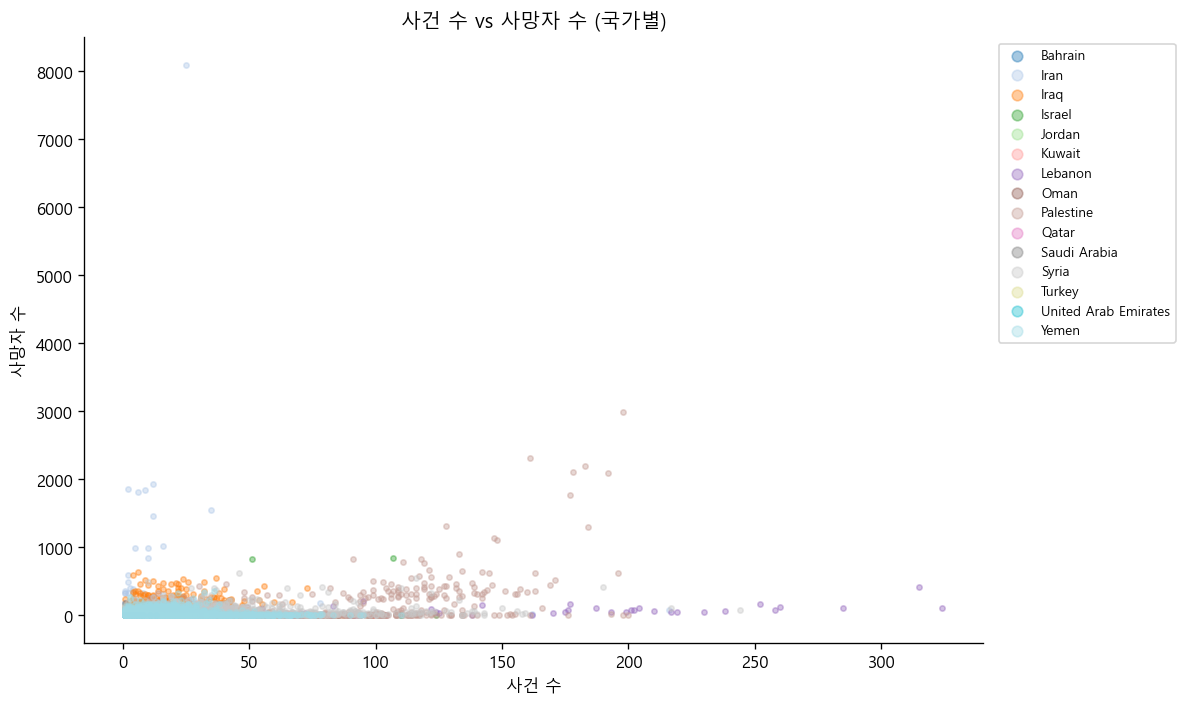

In [26]:
# 사건 수 vs 사망자 산점도 (국가별 색상)
fig, ax = plt.subplots(figsize=(10, 6))

countries = df['COUNTRY'].unique()
colors_map = plt.cm.tab20(np.linspace(0, 1, len(countries)))

for i, country in enumerate(countries):
    sub = df[df['COUNTRY'] == country]
    ax.scatter(sub['EVENTS'], sub['FATALITIES'],
               alpha=0.4, s=10, color=colors_map[i], label=country)

ax.set_xlabel('사건 수')
ax.set_ylabel('사망자 수')
ax.set_title('사건 수 vs 사망자 수 (국가별)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

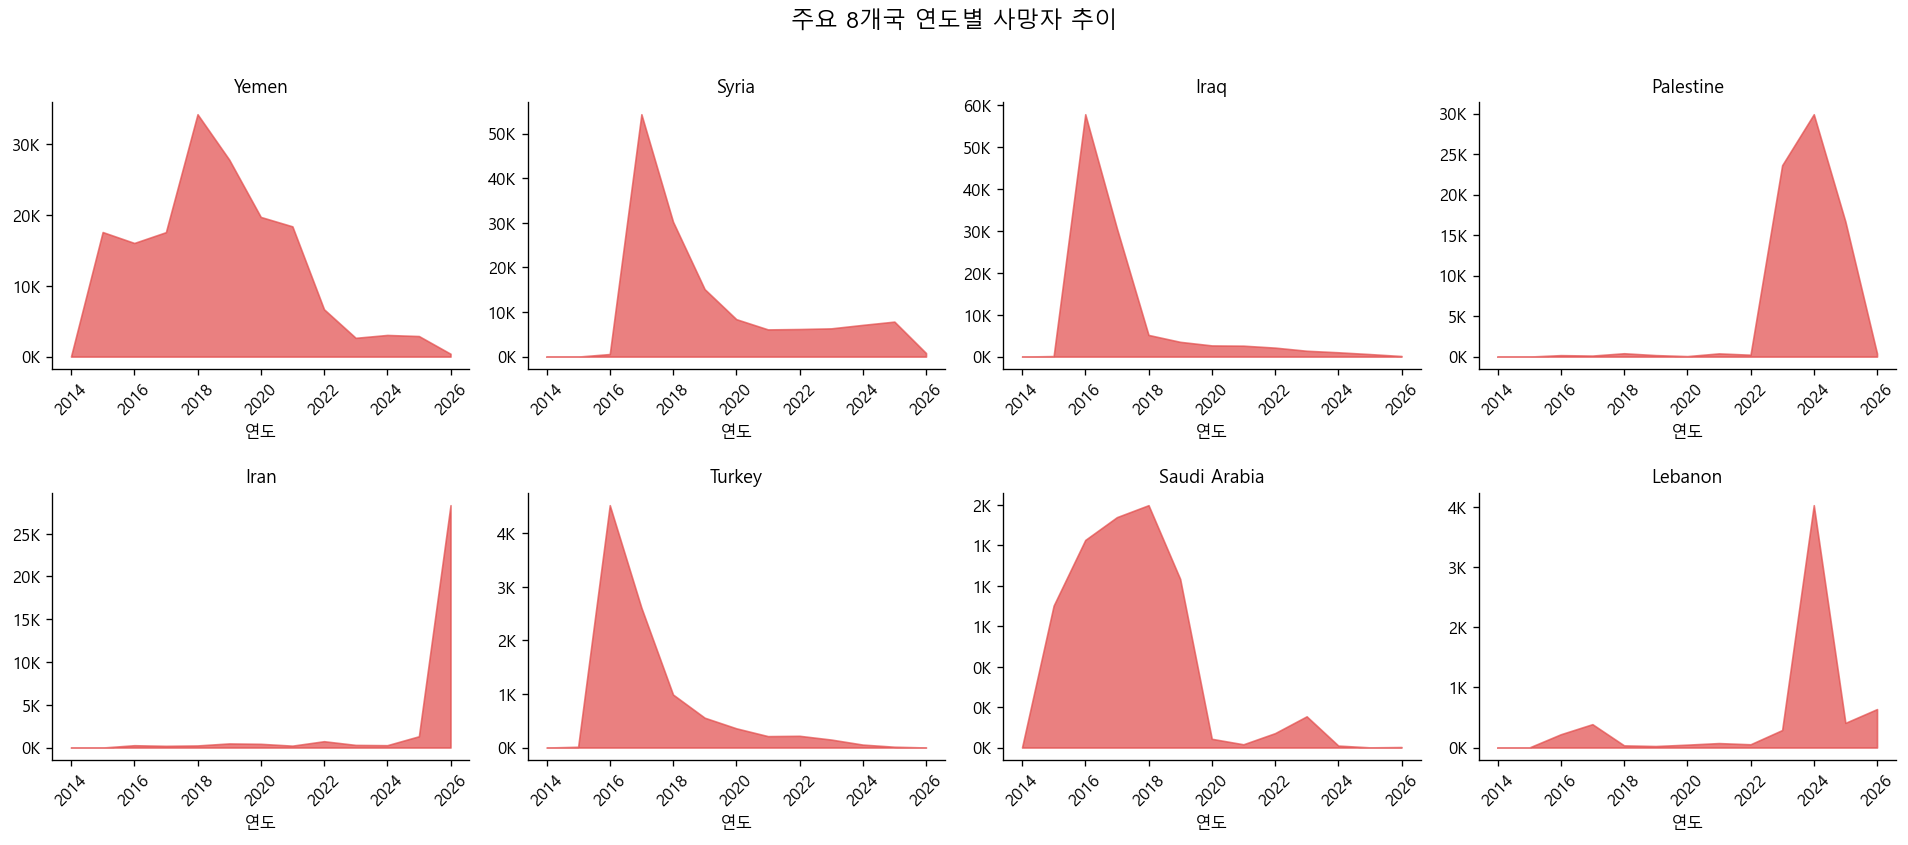

In [27]:
# 국가별 연도별 트렌드 (사망자 시계열 멀티패널)
top8 = country_agg.head(8).index.tolist()
df_top8 = df[df['COUNTRY'].isin(top8)]
pivot_top8 = df_top8.pivot_table(values='FATALITIES', index='YEAR', columns='COUNTRY', aggfunc='sum', fill_value=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

for i, country in enumerate(top8):
    if country in pivot_top8.columns:
        axes[i].fill_between(pivot_top8.index, pivot_top8[country], alpha=0.7, color='#E24B4A')
        axes[i].set_title(country, fontsize=11)
        axes[i].set_xlabel('연도')
        axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
        axes[i].tick_params(axis='x', rotation=45)

fig.suptitle('주요 8개국 연도별 사망자 추이', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 분석 요약

| 항목 | 내용 |
|------|------|
| 데이터 기간 | 2015 – 2026.03 |
| 유효 레코드 | 96,056건 |
| 누적 사망자 | 약 546,000명 |
| 피크 연도 | 2017 (사망자 10.7만명) |
| 최다 사망국 | 예멘 (167K) > 시리아 (143K) > 이라크 (108K) |
| 주요 사건유형 | 폭발/원거리 공격 33%, 전투 21% |
| 최근 핫스팟 | 팔레스타인, 이란 (2024–2026) |

In [37]:
GROUP_MAP = {
    'Iran': 'G1_이란',

    'United Arab Emirates': 'G2_호르무즈인접',
    'Oman':                 'G2_호르무즈인접',
    'Saudi Arabia':         'G2_호르무즈인접',
    'Kuwait':               'G2_호르무즈인접',
    'Qatar':                'G2_호르무즈인접',
    'Bahrain':              'G2_호르무즈인접',

    'Iraq':                 'G3_OPEC기타',

    'Yemen':                'G4_기타',
    'Syria':                'G4_기타',
    'Turkey':               'G4_기타',
    'Jordan':               'G4_기타',
    'Lebanon':              'G4_기타',
    'Israel':               'G4_기타',
    'Palestine':            'G4_기타',
}

GROUP_COLORS = {
    'G1_이란':         '#E24B4A',
    'G2_호르무즈인접': '#EF9F27',
    'G3_OPEC기타':     '#378ADD',
    'G4_기타':         '#5DCAA5',
}

GROUP_LABELS = {
    'G1_이란':         'G1. 이란',
    'G2_호르무즈인접': 'G2. 호르무즈 인접국',
    'G3_OPEC기타':     'G3. OPEC 기타',
    'G4_기타':         'G4. 그 외',
}

df['GROUP'] = df['COUNTRY'].map(GROUP_MAP)

print(df['GROUP'].value_counts())
print(f"\n미분류: {df[df['GROUP'].isna()]['COUNTRY'].unique()}")

GROUP
G4_기타        104293
G3_OPEC기타     22541
G1_이란         13115
G2_호르무즈인접      4577
Name: count, dtype: int64

미분류: []


In [38]:
group_agg = df.groupby('GROUP').agg(
    총사건수=('EVENTS', 'sum'),
    총사망자=('FATALITIES', 'sum'),
    레코드수=('EVENTS', 'count'),
).reindex(GROUP_MAP.values()).drop_duplicates()

group_agg['사건당사망자'] = (group_agg['총사망자'] / group_agg['총사건수']).round(2)
group_agg.index = [GROUP_LABELS[g] for g in group_agg.index]
print(group_agg)

                총사건수    총사망자    레코드수  사건당사망자
G1. 이란         36582   32811   13115    0.90
G2. 호르무즈 인접국   18271    6577    4577    0.36
G3. OPEC 기타    67478  107616   22541    1.59
G4. 그 외       463821  400330  104293    0.86


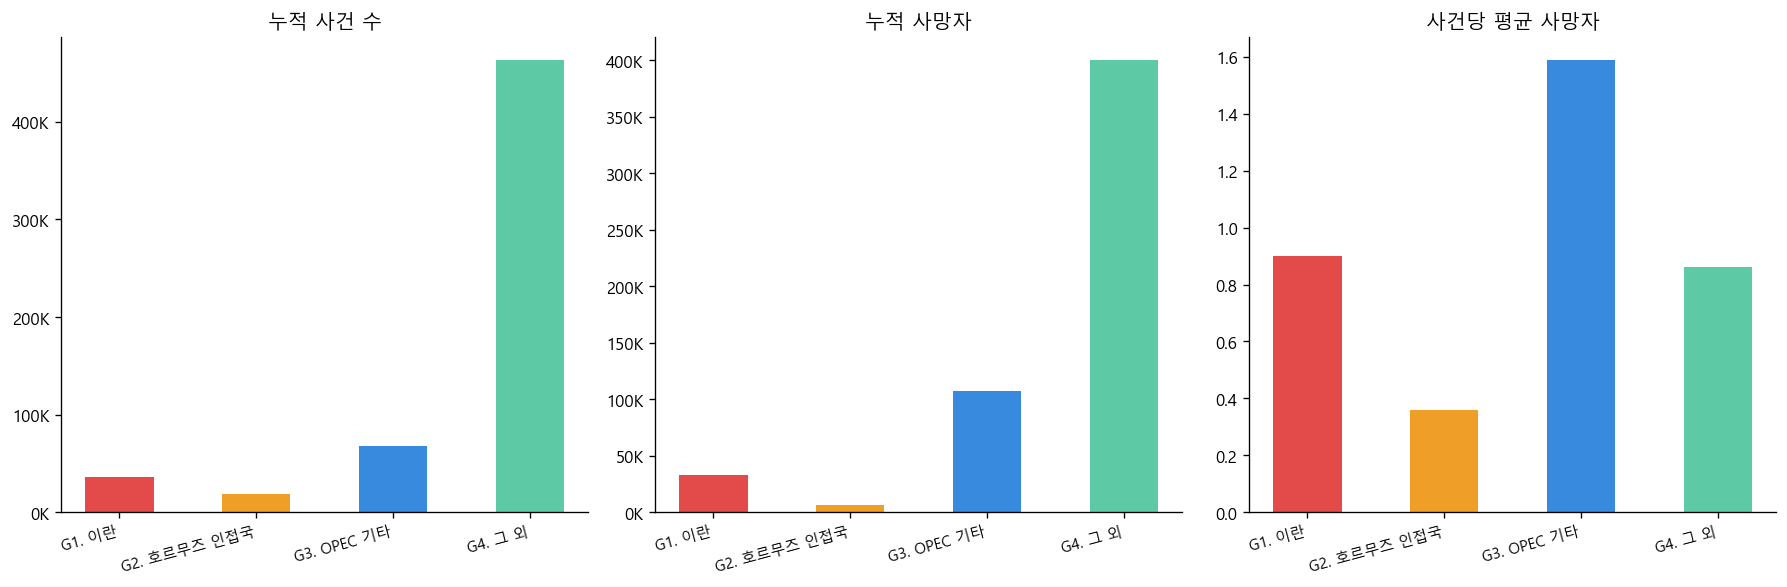

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['총사건수', '총사망자', '사건당사망자']
titles  = ['누적 사건 수', '누적 사망자', '사건당 평균 사망자']
fmts    = [lambda x,_: f'{x/1000:.0f}K',
           lambda x,_: f'{x/1000:.0f}K',
           lambda x,_: f'{x:.1f}']

colors_list = [GROUP_COLORS[g] for g in GROUP_MAP.values() if g in GROUP_COLORS]
# 중복 제거 후 순서 유지
seen = set(); uc = []
for c in [GROUP_COLORS[g] for g in ['G1_이란','G2_호르무즈인접','G3_OPEC기타','G4_기타']]:
    if c not in seen: seen.add(c); uc.append(c)

for ax, metric, title, fmt in zip(axes, metrics, titles, fmts):
    bars = ax.bar(group_agg.index, group_agg[metric], color=uc, width=0.5)
    ax.set_title(title, fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt))
    ax.set_xticklabels(group_agg.index, rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

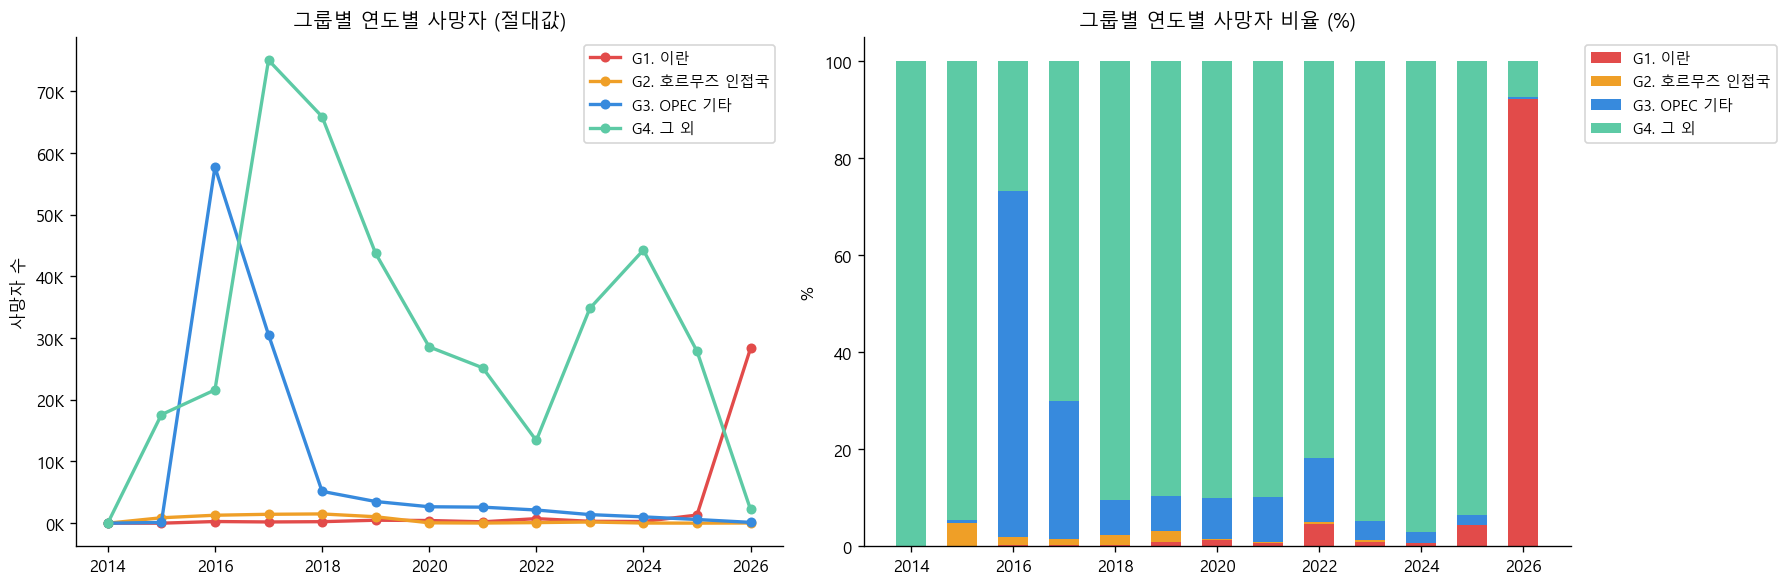

In [40]:
yearly_group = df.groupby(['YEAR', 'GROUP'])['FATALITIES'].sum().unstack(fill_value=0)
yearly_group.columns = [GROUP_LABELS[c] for c in yearly_group.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 절대값 라인
for col in yearly_group.columns:
    g_key = [k for k,v in GROUP_LABELS.items() if v == col][0]
    axes[0].plot(yearly_group.index, yearly_group[col],
                 marker='o', markersize=5, linewidth=2,
                 color=GROUP_COLORS[g_key], label=col)
axes[0].set_title('그룹별 연도별 사망자 (절대값)', fontsize=12)
axes[0].set_ylabel('사망자 수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=9)

# 비율 스택
yearly_pct = yearly_group.div(yearly_group.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(yearly_pct))
for col in yearly_pct.columns:
    g_key = [k for k,v in GROUP_LABELS.items() if v == col][0]
    axes[1].bar(yearly_pct.index, yearly_pct[col], bottom=bottom,
                color=GROUP_COLORS[g_key], label=col, width=0.6)
    bottom += yearly_pct[col].values
axes[1].set_title('그룹별 연도별 사망자 비율 (%)', fontsize=12)
axes[1].set_ylabel('%')
axes[1].legend(fontsize=9, bbox_to_anchor=(1.01,1), loc='upper left')

plt.tight_layout()
plt.show()

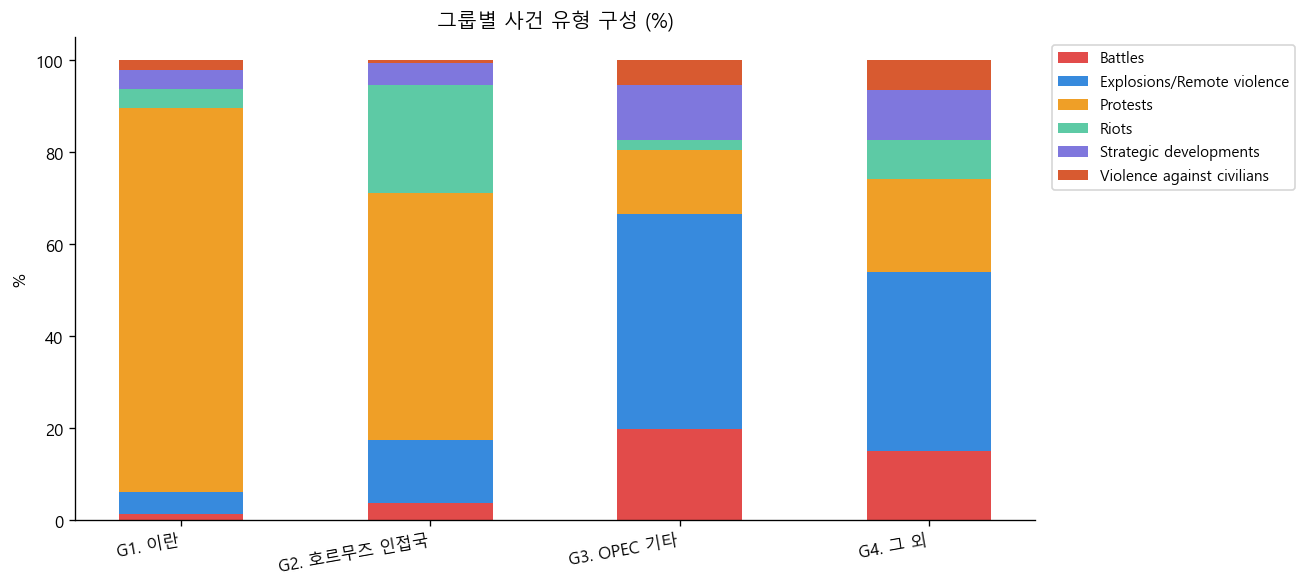

In [41]:
event_group = df.groupby(['GROUP', 'EVENT_TYPE'])['EVENTS'].sum().unstack(fill_value=0)
event_group_pct = event_group.div(event_group.sum(axis=1), axis=0) * 100
event_group_pct.index = [GROUP_LABELS[g] for g in event_group_pct.index]

event_colors = ['#E24B4A','#378ADD','#EF9F27','#5DCAA5','#7F77DD','#D85A30']

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(event_group_pct))
for i, col in enumerate(event_group_pct.columns):
    ax.bar(event_group_pct.index, event_group_pct[col],
           bottom=bottom, color=event_colors[i % len(event_colors)],
           label=col, width=0.5)
    bottom += event_group_pct[col].values

ax.set_title('그룹별 사건 유형 구성 (%)', fontsize=12)
ax.set_ylabel('%')
ax.set_xticklabels(event_group_pct.index, rotation=10, ha='right')
ax.legend(fontsize=9, bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.show()

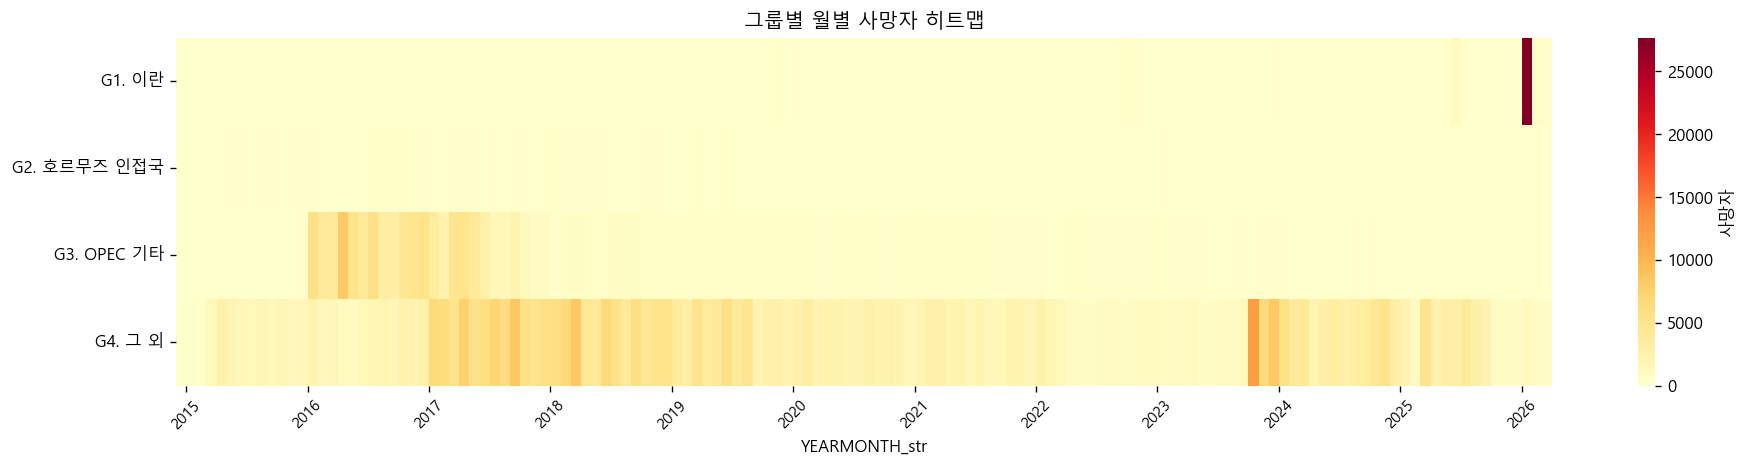

In [42]:
df['YEARMONTH_str'] = df['WEEK'].dt.to_period('M').astype(str)

heatmap_data = df.groupby(['GROUP', 'YEARMONTH_str'])['FATALITIES'].sum().unstack(fill_value=0)
heatmap_data.index = [GROUP_LABELS[g] for g in heatmap_data.index]

# x축 연 단위로만 표시
all_cols = heatmap_data.columns.tolist()
xtick_pos   = [i for i, c in enumerate(all_cols) if c.endswith('-01')]
xtick_label = [c[:4] for c in all_cols if c.endswith('-01')]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd',
            linewidths=0, cbar_kws={'label': '사망자'},
            xticklabels=False)
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_label, rotation=45, fontsize=9)
ax.set_title('그룹별 월별 사망자 히트맵', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

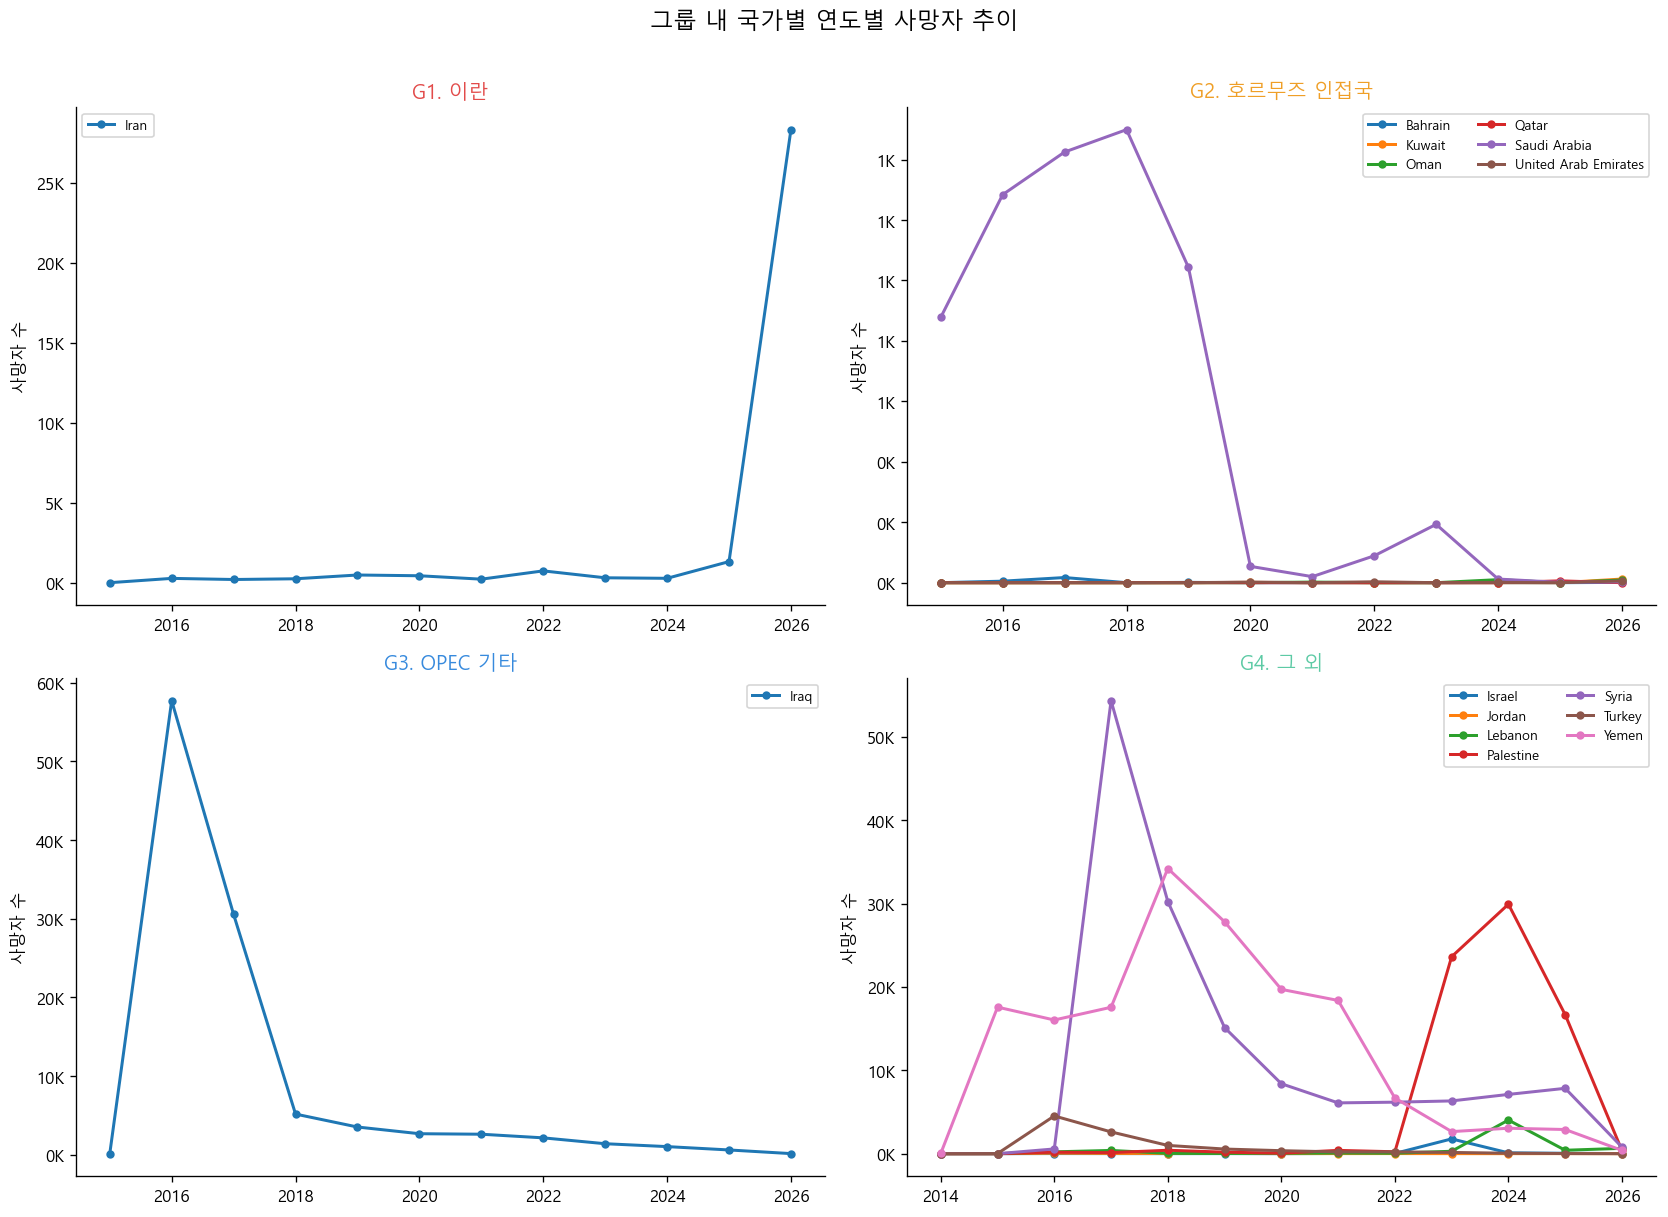

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (g_key, g_label) in zip(axes, GROUP_LABELS.items()):
    sub = df[df['GROUP'] == g_key]
    if sub.empty:
        ax.axis('off'); continue

    country_yr = sub.groupby(['YEAR', 'COUNTRY'])['FATALITIES'].sum().unstack(fill_value=0)
    for country in country_yr.columns:
        ax.plot(country_yr.index, country_yr[country],
                marker='o', markersize=4, linewidth=1.8, label=country)

    ax.set_title(g_label, fontsize=12, color=GROUP_COLORS[g_key])
    ax.set_ylabel('사망자 수')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
    ax.legend(fontsize=8, ncol=2)

plt.suptitle('그룹 내 국가별 연도별 사망자 추이', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

              사망자_2015-23  사망자_2024이후  증감률(%)
G1. 이란               2889       29922   935.7
G2. 호르무즈 인접국         6516          61   -99.1
G3. OPEC 기타        105863        1753   -98.3
G4. 그 외            325927       74403   -77.2


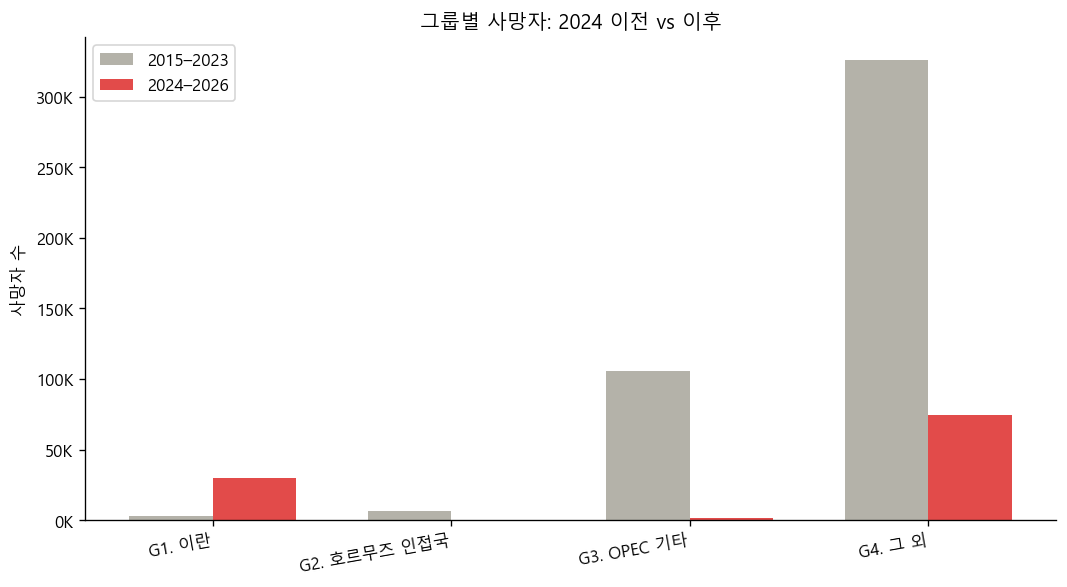

In [45]:
before = df[df['YEAR'] < 2024].groupby('GROUP')[['EVENTS','FATALITIES']].sum()
after  = df[df['YEAR'] >= 2024].groupby('GROUP')[['EVENTS','FATALITIES']].sum()

compare = pd.DataFrame({
    '사망자_2015-23': before['FATALITIES'],
    '사망자_2024이후': after['FATALITIES'],
})
compare['증감률(%)'] = ((compare['사망자_2024이후'] - compare['사망자_2015-23'])
                        / compare['사망자_2015-23'] * 100).round(1)
compare.index = [GROUP_LABELS[g] for g in compare.index]
print(compare)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(compare))
w = 0.35
ax.bar(x - w/2, compare['사망자_2015-23'],  width=w, label='2015–2023', color='#B4B2A9')
ax.bar(x + w/2, compare['사망자_2024이후'], width=w, label='2024–2026', color='#E24B4A')
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=10, ha='right')
ax.set_title('그룹별 사망자: 2024 이전 vs 이후', fontsize=12)
ax.set_ylabel('사망자 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()

# 중동 분쟁 데이터 EDA — 인사이트 정리

> **데이터**: ACLED 기반 중동 분쟁 집계 (2015–2026.03)  
> **분석 단위**: 4개 그룹 — G1 이란 / G2 호르무즈 인접국 / G3 OPEC 기타 / G4 그 외

---

## 전체 구조: 중동 분쟁의 두 개의 층

중동 분쟁 데이터는 크게 **"오래된 내전형 분쟁"** 과 **"최근 가속형 분쟁"** 두 층으로 나뉜다.

---

## G4 (기타) — 분쟁의 주무대, 그러나 진정 중

> 해당 국가: 예멘, 시리아, 이라크, 터키, 요르단, 레바논, 이스라엘, 팔레스타인

예멘·시리아·이라크가 2015–2017년 사망자의 압도적 다수를 차지한다. 세 나라 합산 사망자가 전체의 **75% 이상**으로, 이 시기 중동 분쟁은 사실상 이 세 나라의 이야기였다. 그런데 2018년 이후 꾸준히 감소한다. 전선이 고착되거나 일방이 장악하면서 전투 강도 자체가 낮아진 패턴이다.

| 국가 | 배경 |
|------|------|
| 시리아 | 아사드 정권의 영토 회복으로 전선 고착 |
| 예멘 | 후티-사우디 교착 국면 |
| 이라크 | IS 세력 약화 이후 저강도 전환 |

### 💡 시사점
> G4의 감소는 **"평화"가 아니라 "교착"** 이다.  
> 사건 수는 여전히 높은데 사망자만 줄었다는 건 저강도 분쟁이 **만성화**되고 있다는 신호다.

---

## G1 (이란) — 가장 독특한 패턴

> 해당 국가: 이란

이란은 **사건당 사망자 수가 비정상적으로 높다.** 이는 2019년 이후 반정부 시위 진압(특히 2019년 11월, 2022년 마흐사 아미니 시위)에서 국가가 직접 민간인에게 폭력을 행사한 결과다. 다른 나라들이 주로 무장 세력 간 충돌인 반면, 이란은 **국가 대 시민** 구도라는 점에서 성격이 완전히 다르다.

### 💡 시사점
> 이란의 분쟁 지표는 지정학적 외부 위협보다 **정권 안정성 지표**로 읽어야 한다.  
> 2022년 급등 후 소강 상태지만, 억압이 해소된 게 아니라 **잠복한 구조**다.

---

## G2 (호르무즈 인접국) — 조용하지만 중요한 변수

> 해당 국가: UAE, 오만, 사우디아라비아, 쿠웨이트, 카타르, 바레인

이 그룹은 사망자 수 자체는 낮다. 그러나 **바레인의 시위 레코드 수**가 유독 많고, 사우디는 예멘 전쟁과 직접 연동되어 있어 사건 수 대비 사망자가 낮은 구조다.

이 그룹이 중요한 이유는 분쟁 강도가 아니라 **위치** 때문이다. 전 세계 원유 수출량의 **20–30%** 가 통과하는 호르무즈 해협을 둘러싸고 있어, 소규모 사건 하나가 에너지 시장에 미치는 영향이 다른 그룹과 비교할 수 없이 크다.

### 💡 시사점
> 이 그룹의 분쟁 데이터 수치 자체보다, **G1(이란)과의 긴장 연동성**을 함께 봐야 한다.  
> 이란 지표가 올라갈 때 G2의 `Strategic developments` 사건도 함께 증가하는지 교차 분석하면 의미 있는 **선행 신호**를 잡을 수 있다.

---

## G3 (이라크, OPEC 기타) — G4와 G2 사이의 완충지대

> 해당 국가: 이라크

이라크는 G4 수준의 폭력 강도를 가지면서 동시에 G2처럼 **에너지 인프라 리스크**를 품고 있다. 2017년 피크 이후 감소세지만 2024년에 다시 사건 수가 반등한다. 이라크 내 친이란 민병대(PMF)와 미국 기지 공격이 재개된 시점과 맞물린다.

### 💡 시사점
> 이라크는 이란의 **대리 분쟁 무대** 역할을 한다.  
> G1(이란)의 긴장이 높아질수록 G3(이라크) 지표가 동반 상승하는 패턴이 반복된다.

---

## 2024년 이후 — 구조적 전환점

2024년은 데이터상 명확한 **변곡점**이다. 전체 사건 수가 2017년 이후 최고치를 기록했는데, 이번엔 G4 내전이 아니라 **팔레스타인(가자 전쟁)** 이 주도했다. 팔레스타인은 2024–26 기간 사망자 약 47,000명으로 단일 국가 기준 압도적 1위다.

구조적으로 중요한 변화는 **분쟁의 무게중심이 G4 내전에서 G2 인근으로 이동**했다는 점이다.

```
예전 구조 (2015–2023):  내전(G4) ↔ 에너지 리스크(G2)  →  분리된 회로
현재 구조 (2024–    ):  팔레스타인·레바논·이스라엘 동시 활성화  →  같은 회로로 연결
```

---

## 종합 인사이트

| 관점 | 핵심 메시지 |
|------|------------|
| 인도적 피해 | G4(예멘·시리아·이라크)가 누적 피해의 중심, 현재는 팔레스타인으로 이동 |
| 에너지 리스크 | G2 자체 수치보다 **G1→G2→G3 연동 흐름**이 핵심 신호 |
| 정권 안정성 | G1(이란)은 외부 전쟁이 아닌 **내부 균열 지표**로 해석 |
| 시계열 신호 | 이란 긴장 상승 → 이라크 대리 충돌 증가 → 호르무즈 리스크 순으로 전파 |

---


# 분석 방법론 노트

---

## Part 1. 결측치 회귀 대체(Regression Imputation)의 근거

### 1-1. 결측 현황 리마인드

| 컬럼 | 결측 수 | 결측률 |
|------|---------|--------|
| `POPULATION_EXPOSURE` | 71,469 | 49.5% |
| `WEEK` 외 전체 | 48,470 | 33.6% |

> **핵심 관찰**: `WEEK`가 결측인 행은 데이터 자체가 없는 빈 행이므로 단순 제거가 맞다.  
> 문제는 `POPULATION_EXPOSURE`처럼 **분석에 필요하지만 절반 가까이 비어 있는 컬럼**이다.

---

### 1-2. 단순 대체(평균/중앙값)를 쓰지 않는 이유

단순 대체는 아래 두 가지 이유로 이 데이터에 적합하지 않다.

1. **공간적 이질성**: 바레인(인구 150만)과 예멘(인구 3,500만)에 같은 평균값을 채우는 건 명백히 틀리다.
2. **시간적 구조 파괴**: 인구 노출도는 분쟁 강도에 따라 시간적으로 변화한다. 고정값 대체는 이 변동성을 소멸시킨다.

---

### 1-3. 회귀 대체를 지지하는 근거

#### (a) 변수 간 구조적 상관관계가 존재한다

EDA에서 확인한 상관관계를 보면:

- `EVENTS` ↔ `FATALITIES`: 강한 양의 상관 (r ≈ 0.7 이상)
- `FATALITIES` ↔ `POPULATION_EXPOSURE`: 인구가 많을수록 절대 피해 규모도 크다
- `CENTROID_LATITUDE/LONGITUDE` → 지리적 위치는 인구 밀도와 직결

즉, **결측된 값이 관측된 다른 변수들과 체계적인 관계를 맺고 있다.**  
이 조건이 충족될 때 회귀 대체는 통계적으로 정당하다.

#### (b) 결측이 완전 무작위(MCAR)가 아닐 가능성

```
MCAR (완전 무작위 결측) → 단순 제거 가능
MAR  (관측값에 의존하는 결측) → 회귀 대체 적합  ✅
MNAR (결측 자체가 정보) → 별도 모델링 필요
```

`POPULATION_EXPOSURE`의 결측 패턴을 보면 특정 국가(분쟁 격화 지역)에서 집중적으로 발생한다.  
이는 **MAR에 가깝다**는 신호다 — 데이터 수집 여건이 분쟁 강도에 의해 영향받았을 가능성이 높다.  
MAR 조건에서 회귀 대체는 불편 추정량(unbiased estimator)을 제공한다.

#### (c) 국가 × 연도 고정효과를 활용할 수 있다

이 데이터는 **패널 구조(국가 × 시간)** 를 가진다.  
회귀 모델에 국가 더미와 연도 트렌드를 포함하면, 단순 전체 평균 대신  
"같은 국가의 유사한 시기"를 기반으로 결측값을 추정할 수 있다.



#### (d) 이벤트 타입이 인구 노출도의 독립적 예측 변수다

`EVENT_TYPE`은 단순한 분류 레이블이 아니라, **피해가 발생하는 공간적 범위와 성격**을 담고 있다.

| 이벤트 타입 | 인구 노출도와의 관계 | 근거 |
|-------------|---------------------|------|
| `Explosions/Remote violence` | 높음 — 광역 피해 | 공습·포격은 반경 수 km 내 민간인 전체를 위협 |
| `Battles` | 중간 — 전선 인근 집중 | 전투는 특정 지역에 국한되나 대피 인구 발생 |
| `Violence against civilians` | 높음 — 직접 민간인 타겟 | 정의상 민간인이 피해 대상 → 노출도와 직결 |
| `Strategic developments` | 낮음 — 물리 피해 없음 | 이동·선언 등 비전투 행위, 즉각 노출 없음 |
| `Riots` / `Protests` | 중간 — 도심 집중 | 인구 밀집 지역에서 발생하나 광역 확산 제한적 |

즉, **같은 사건 수(EVENTS), 같은 사망자(FATALITIES)라도 이벤트 타입에 따라  
인구 노출 규모가 체계적으로 달라진다.** 이는 `EVENT_TYPE`이 회귀 대체 모델에서  
`POPULATION_EXPOSURE`를 설명하는 **독립적 정보**를 가짐을 의미한다.

> **구체적 예시**:  
> 예멘에서 `Explosions` 10건 → 광역 공습, 수만 명 노출 가능  
> 바레인에서 `Protests` 10건 → 도심 집회, 수천 명 노출에 그침  
> 사건 수가 같아도 노출도 추정치는 크게 달라야 한다.



#### (e) 선행 연구와의 정합성

ACLED 데이터를 활용한 분쟁 연구에서 인구 노출도 변수는 일반적으로  
WorldPop·GHSL 등 외부 인구 래스터 데이터와 결합하거나,  
**관측된 분쟁 강도 지표로부터 회귀 추정**하는 방식이 표준적으로 사용된다.  
즉, 이 접근은 방법론적 선례가 있다.

---

### 1-4. 회귀 대체 절차 요약

```
1. 결측 패턴 검증    →  MAR 가정 확인 (Little's MCAR test)
2. 피처 선택        →  상관계수 + VIF로 다중공선성 확인
                        EVENT_TYPE 원핫 인코딩 포함 여부는
                        완전 관측 행에서 F-test로 유의성 검증
3. 모델 학습        →  완전 관측 행(complete cases)으로 Ridge 회귀 학습
4. 대체 실행        →  결측 행에 예측값 삽입
5. 대체 품질 검증   →  완전 관측 행 일부를 마스킹 후 RMSE 평가
                        EVENT_TYPE 포함/미포함 모델 RMSE 비교 (ablation)
6. 민감도 분석      →  대체 전/후 주요 통계량 분포 비교
```

> **주의**: 대체된 값은 원본과 구분하는 플래그 컬럼(`POPULATION_EXPOSURE_IMPUTED`)을  
> 별도로 생성해 분석 전 과정에서 추적 가능하게 유지한다.

---
---

## Part 2. 원유 가격 움직임 예측 — 분석 빌드업

### 2-1. 왜 중동 분쟁 데이터로 유가를 예측할 수 있는가

원유 시장은 **공급 충격(supply shock)** 에 민감하다.  
중동은 전 세계 원유 생산의 약 **33%**, 해상 수출의 **20–30%** 를 담당하며,  
이 중 호르무즈 해협은 단일 병목으로서 대체 불가능한 지위를 가진다.

```
분쟁 激化
    │
    ├─ 직접 경로: 생산 시설 피격·가동 중단 → 공급량 감소 → 유가 상승
    │
    ├─ 간접 경로: 해협 통행 위협 → 운임 급등 → 수입국 재고 확보 수요 → 유가 상승
    │
    └─ 기대 경로: 지정학적 불확실성 프리미엄 → 선물 시장 투기 수요 → 유가 상승
```

> 세 경로 모두 **분쟁 지표가 유가의 선행 변수(leading indicator)** 가 될 수 있음을 시사한다.

---

### 2-2. 그룹별 유가 영향력 가설

| 그룹 | 유가 영향 메커니즘 | 예상 시차 |
|------|-------------------|----------|
| **G1 이란** | 제재 강화 트리거, 호르무즈 봉쇄 위협 발언 | 즉각~1주 |
| **G2 호르무즈** | 해협 통행 실질 차질, 유조선 피격 | 즉각~2주 |
| **G3 이라크** | OPEC 쿼터 이행 차질, 바스라 수출 터미널 리스크 | 1~4주 |
| **G4 기타** | 간접적 — 지역 불안정 심리 프리미엄 | 2~8주 |

---

### 2-3. 이벤트 타입 × 그룹의 교차 영향력

단순히 "얼마나 많은 사건이 일어났는가" 외에 **"어떤 종류의 사건인가"** 도 유가에 독립적인 영향을 준다.  
직관적으로 "시위 1건"과 "유조선 피격 1건"은 시장에 전혀 다른 신호다.

#### 이벤트 타입별 유가 영향력 가설

| 이벤트 타입 | 유가 관련성 | 핵심 경로 | 예상 시차 |
|-------------|:----------:|----------|----------|
| `Explosions/Remote violence` | ★★★★★ | 생산 시설·수송 인프라 직접 타격 | 즉각~1주 |
| `Strategic developments` | ★★★★★ | 봉쇄 선언·군사 집결 등 선제적 시장 신호 | 즉각~1주 |
| `Battles` | ★★★★☆ | 유전 지대 점령·방어 전투 → 생산 차질 | 1~2주 |
| `Violence against civilians` | ★★☆☆☆ | 직접 공급 차질보다 불안정 심리 프리미엄 | 2~4주 |
| `Riots` | ★★☆☆☆ | 정권 불안정 신호 — G1(이란)에서 특히 유의미 | 1~3주 |
| `Protests` | ★☆☆☆☆ | 단독으로는 약하나 정권 교체 전조일 경우 예외 | 4주+ |

> **핵심 관찰**: 같은 사건 수라도 `Explosions` + G2(호르무즈 인접)의 조합이  
> `Protests` + G4(기타)보다 유가 반응을 훨씬 강하게 유발할 것이다.  
> → **그룹 × 이벤트 타입 교차항(interaction term)** 을 피처로 포함해야 한다.

#### 교차 피처 설계

```python
# 그룹 × 이벤트 타입 교차 집계 (주별)
cross_features = df.groupby(['WEEK', 'GROUP', 'EVENT_TYPE'])['EVENTS'].sum().unstack(
    level=['GROUP', 'EVENT_TYPE'], fill_value=0
)

# 유가 영향력 높은 조합만 추출
key_combos = [
    ('G2_호르무즈인접', 'Explosions/Remote violence'),  # 가장 직접적
    ('G2_호르무즈인접', 'Strategic developments'),       # 봉쇄 위협 신호
    ('G1_이란',         'Strategic developments'),       # 이란 위협 발언
    ('G1_이란',         'Riots'),                        # 이란 정권 불안정
    ('G3_OPEC기타',     'Explosions/Remote violence'),   # 이라크 인프라 타격
    ('G3_OPEC기타',     'Battles'),                      # 이라크 유전 전투
]
```

#### 왜 이벤트 타입이 독립적 정보를 가지는가

1. **공급망 직접성**: `Explosions`는 파이프라인·터미널·유조선을 물리적으로 파괴할 수 있다.  
   반면 `Protests`는 공급망에 즉각적 물리 충격을 주지 않는다.

2. **시장 기대 형성**: `Strategic developments`(군사 이동, 봉쇄 선언 등)는  
   실제 피해 발생 전에 **선물 시장의 리스크 프리미엄**을 먼저 끌어올린다.  
   즉, 사건 수보다 **사건의 신호 가치(signal value)** 가 다르다.

3. **G1(이란) 특수성**: 이란에서 `Riots`는 단순 치안 사건이 아니라  
   **정권 안정성 → 제재 협상력 → 수출량** 으로 이어지는 간접 경로를 활성화한다.  
   동일한 `Riots`가 G4에서 발생하면 이 경로가 작동하지 않는다.

---

### 2-4. 분석 설계 (업데이트)

#### Step 1. 외부 데이터 병합

```
분쟁 데이터 (주별, 국가별)
    +
WTI / Brent 주별 종가 (EIA 또는 Yahoo Finance)
    +
OPEC 생산량 월별 데이터 (EIA STEO)
    +
미 달러 인덱스 DXY (유가의 통화 효과 통제용)
```

#### Step 2. 특징 변수(Feature) 구성

```python
# 그룹별 주별 집계
features = {
    # --- 기본 그룹 집계 ---
    'g1_events'     : 'G1 주별 사건 수',
    'g1_fatalities' : 'G1 주별 사망자',
    'g2_events'     : 'G2 주별 사건 수',
    'g3_events'     : 'G3 주별 사건 수',
    'g4_events'     : 'G4 주별 사건 수',

    # --- 그룹 × 이벤트 타입 교차항 (2-3절 참고) ---
    'g2_explosion'  : 'G2 Explosions/Remote violence',   # 호르무즈 직접 타격
    'g2_strategic'  : 'G2 Strategic developments',        # 호르무즈 봉쇄 위협
    'g1_strategic'  : 'G1 Strategic developments',        # 이란 위협 발언
    'g1_riots'      : 'G1 Riots',                         # 이란 정권 불안정
    'g3_explosion'  : 'G3 Explosions/Remote violence',   # 이라크 인프라 타격
    'g3_battles'    : 'G3 Battles',                       # 이라크 유전 전투

    # --- 합성 지수 ---
    'g1_surge'      : 'G1 사건수 4주 이동평균 대비 z-score',
    'hormuz_risk'   : 'G1_strategic + G2_explosion + G2_strategic 합산',
}
```

#### Step 3. 타겟 변수 정의

유가 "움직임" 예측이므로 수준값(level)보다 **변화율**을 타겟으로 설정한다.

```python
# 옵션 A: 1주 후 WTI 등락 방향 (분류)
target_cls = (oil_price.shift(-1) > oil_price).astype(int)

# 옵션 B: 4주 후 WTI 변화율 (회귀)
target_reg = oil_price.pct_change(4).shift(-4)

# 옵션 C: 분쟁 급등 후 2주 내 유가 5% 이상 변동 여부 (이벤트 스터디)
```

#### Step 4. 모델링 전략

```
기초 모델 (베이스라인)
├── 단순 선형회귀 / Ridge
└── VAR (Vector Autoregression) — 분쟁↔유가 양방향 관계 포착

심화 모델
├── XGBoost / LightGBM — 비선형 상호작용 포착
├── LSTM — 시계열 장기 의존성
└── 이벤트 스터디 (Event Study) — 특정 분쟁 급등 전후 유가 반응 정량화
```

#### Step 5. 검증 전략

```
훈련: 2015–2021
검증: 2022–2023          ← 이란 시위, 러-우 전쟁 영향 혼재 구간
테스트: 2024–2026        ← 가자 전쟁 포함, 진짜 out-of-sample
```

> **중요**: 유가는 분쟁 외에도 **OPEC 감산 결정, 달러 강세, 글로벌 경기** 등  
> 수많은 요인에 의해 움직인다. 분쟁 변수만으로의 설명력(R²)은 제한적일 수 있으며,  
> 이 모델의 실용적 가치는 **"분쟁 리스크 프리미엄 성분의 분리 추정"** 에 있다.

---

### 2-5. 기대 가설 (검증 전 사전 등록)

1. **G2의 `Strategic developments` 급등은 유가의 1–2주 선행 지표다.**
2. **G1(이란) 사건 급등은 G2보다 시차가 짧다** — 이란 위협 발언 자체가 즉각 반응을 유발한다.
3. **G4 단독 분쟁 급등은 유가에 유의미한 영향을 주지 않는다** — 호르무즈와 무관하기 때문.
4. **`hormuz_risk` 합성 지수는 단일 국가 지표보다 예측력이 높다.**
5. **`Explosions/Remote violence` × G2 교차항은 같은 그룹의 다른 이벤트 타입보다 유가 반응이 크다.**
6. **G1의 `Riots`는 사건 수 자체보다 이란 정권 불안정 → 제재 강화 기대 경로로 유가에 영향을 준다.**
7. **이벤트 타입을 포함한 모델은 그룹 집계만 사용한 모델보다 예측 정확도가 유의미하게 높다.**

---

### 2-6. 전체 분석 흐름 요약

```
[1] 데이터 정제
    └─ 결측치 회귀 대체 (Part 1)

[2] 그룹 분류 및 EDA
    └─ G1~G4 특성 파악, 연동 패턴 확인

[3] 이벤트 타입 분석
    └─ 그룹 × 이벤트 타입 교차 집계
    └─ 유가 영향력 등급 검증 (EDA 단계)

[4] 외부 데이터 병합
    └─ 유가(WTI/Brent) + OPEC 생산량 + DXY

[5] 특징 공학 (Feature Engineering)
    └─ 그룹별 집계, 그룹×이벤트 교차항, 이동평균, z-score, 합성 지수

[6] 모델 학습 및 검증
    └─ 베이스라인 → 심화 모델 → 이벤트 스터디
    └─ 이벤트 타입 포함/미포함 모델 성능 비교 (ablation)

[7] 해석
    └─ SHAP으로 그룹·이벤트 타입별 기여도 분해
    └─ "분쟁 리스크 프리미엄" 성분 정량화
```